# **1. Import Data and Library**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, cross_val_score, learning_curve, validation_curve, StratifiedKFold)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import time
from sklearn.datasets import load_wine, load_digits, load_iris
import warnings
warnings.filterwarnings('ignore')


data = pd.read_csv("../Data/ObesityDataSet_raw_and_data_sinthetic.csv")
data


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


# **2. Preprocessing**

### a. Mengetahui Jenis Data Setiap Kolom

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

### b.  Cek Missing Value, Duplikat, dan Outlier

Missing Value per Kolom:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Total Missing Value: 0

Jumlah Data Duplikat: 24

Semua Data Duplikat:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
467,Male,22.0,1.74,75.0,yes,yes,3.0,3.0,Frequently,no,1.0,no,1.0,0.0,no,Automobile,Normal_Weight
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight



Jumlah Outlier per Kolom:
Age       168
Height      1
Weight      1
FCVC        0
NCP       579
CH2O        0
FAF         0
TUE         0
dtype: int64

Total Baris yang Mengandung Outlier: 702


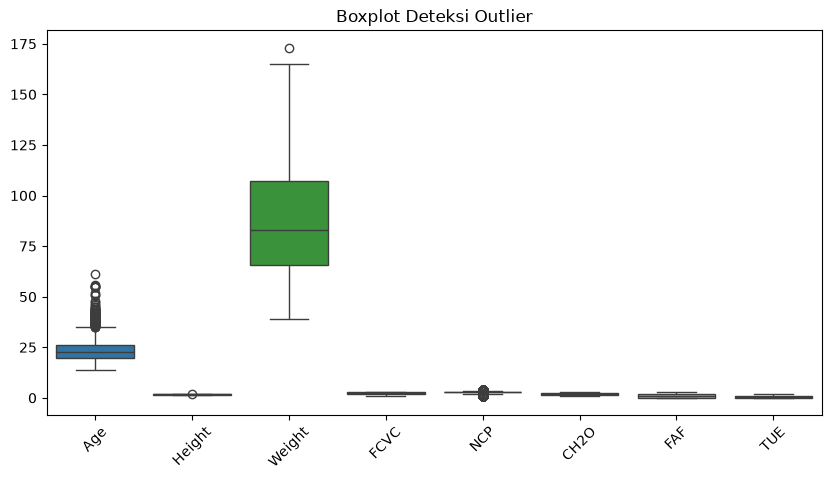

In [5]:
missing = data.isnull().sum()

print("Missing Value per Kolom:")
print(missing)

print("\nTotal Missing Value:", missing.sum())

duplicate = data.duplicated().sum()

print("\nJumlah Data Duplikat:", duplicate)

if duplicate > 0:
    print("\nSemua Data Duplikat:")
    display(data[data.duplicated()])

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

Q1 = data[numerical_cols].quantile(0.25)
Q3 = data[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outlier = ((data[numerical_cols] < (Q1 - 1.5 * IQR)) |
           (data[numerical_cols] > (Q3 + 1.5 * IQR)))

print("\nJumlah Outlier per Kolom:")
print(outlier.sum())

print("\nTotal Baris yang Mengandung Outlier:", outlier.any(axis=1).sum())

plt.figure(figsize=(10,5))
sns.boxplot(data=data[numerical_cols])
plt.title("Boxplot Deteksi Outlier")
plt.xticks(rotation=45)
plt.show()

### c.  Hapus Data duplikat dan Outlier

In [6]:
data_clean = data.drop_duplicates()
print("\nJumlah Data Setelah Menghapus Duplikat:", len(data_clean))

numerical_cols = data_clean.select_dtypes(include=['int64', 'float64']).columns
Q1 = data_clean[numerical_cols].quantile(0.25)
Q3 = data_clean[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((data_clean[numerical_cols] < (Q1 - 1.5 * IQR)) | (data_clean[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

data_clean = data_clean[~outlier_mask]
print("\nJumlah Data Setelah Menghapus Outlier:", len(data_clean))

data_clean


Jumlah Data Setelah Menghapus Duplikat: 2087

Jumlah Data Setelah Menghapus Outlier: 1388


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
5,Male,29.000000,1.620000,53.000000,no,yes,2.0,3.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Automobile,Normal_Weight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


### d. Encode Data Kategorik Menjadi Numerik

In [7]:
mappings = {
    'Gender': {'Female': 0, 'Male': 1},
    'family_history_with_overweight': {'no': 0, 'yes': 1},
    'FAVC': {'no': 0, 'yes': 1},
    'CAEC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'SMOKE': {'no': 0, 'yes': 1},
    'SCC': {'no': 0, 'yes': 1},
    'CALC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'MTRANS': {'Walking': 0, 'Bike': 1, 'Public_Transportation': 2, 'Motorbike': 3, 'Automobile': 4},
    'NObeyesdad': {
        'Insufficient_Weight': 0,
        'Normal_Weight': 1,
        'Overweight_Level_I': 2,
        'Overweight_Level_II': 3,
        'Obesity_Type_I': 4,
        'Obesity_Type_II': 5,
        'Obesity_Type_III': 6
    }
}

def encode_categorical(df, mappings):
    df = df.copy()  # biar aman tidak overwrite langsung
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    print("\nKolom kategori:", list(categorical_cols))
    
    for col in categorical_cols:
        print(f"\nMapping kolom: {col}")
        print("Sebelum:", df[col].unique())
        
        if col in mappings:
            df[col] = df[col].map(mappings[col])
        else:
            print(f"⚠️ Tidak ada mapping untuk {col}")
        
        print("Sesudah:", df[col].unique())
    
    return df

data = encode_categorical(data, mappings)
data_clean = encode_categorical(data_clean, mappings)


Kolom kategori: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

Mapping kolom: Gender
Sebelum: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Sesudah: [0 1]

Mapping kolom: family_history_with_overweight
Sebelum: <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
Sesudah: [1 0]

Mapping kolom: FAVC
Sebelum: <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
Sesudah: [0 1]

Mapping kolom: CAEC
Sebelum: <ArrowStringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str
Sesudah: [1 2 3 0]

Mapping kolom: SMOKE
Sebelum: <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
Sesudah: [0 1]

Mapping kolom: SCC
Sebelum: <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
Sesudah: [0 1]

Mapping kolom: CALC
Sebelum: <ArrowStringArray>
['no', 'Sometimes', 'Frequently', 'Always']
Length: 4, dtype: str
Sesudah: [0 1 2 3]

Mapping kolom: MTRANS
Sebelum: <ArrowStringArray>
['Public_Transportatio

In [8]:
data

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,1,0,2.000000,0,0.000000,1.000000,0,2,1
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,1,1,3.000000,1,3.000000,0.000000,1,2,1
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,1,0,2.000000,0,2.000000,1.000000,2,2,1
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,1,0,2.000000,0,2.000000,0.000000,2,0,2
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,1,0,2.000000,0,0.000000,0.000000,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,1,0,1.728139,0,1.676269,0.906247,1,2,6
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,1,0,2.005130,0,1.341390,0.599270,1,2,6
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,1,0,2.054193,0,1.414209,0.646288,1,2,6
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,1,0,2.852339,0,1.139107,0.586035,1,2,6


In [9]:
data_clean

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,1,0,2.000000,0,0.000000,1.000000,0,2,1
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,1,1,3.000000,1,3.000000,0.000000,1,2,1
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,1,0,2.000000,0,2.000000,1.000000,2,2,1
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,1,0,2.000000,0,2.000000,0.000000,2,0,2
5,1,29.000000,1.620000,53.000000,0,1,2.0,3.0,1,0,2.000000,0,0.000000,0.000000,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,1,0,1.728139,0,1.676269,0.906247,1,2,6
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,1,0,2.005130,0,1.341390,0.599270,1,2,6
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,1,0,2.054193,0,1.414209,0.646288,1,2,6
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,1,0,2.852339,0,1.139107,0.586035,1,2,6


In [10]:
pcc = data.drop(columns=['NObeyesdad']).corr('pearson')
pcc_clean = data_clean.drop(columns=['NObeyesdad']).corr('pearson')

<Axes: >

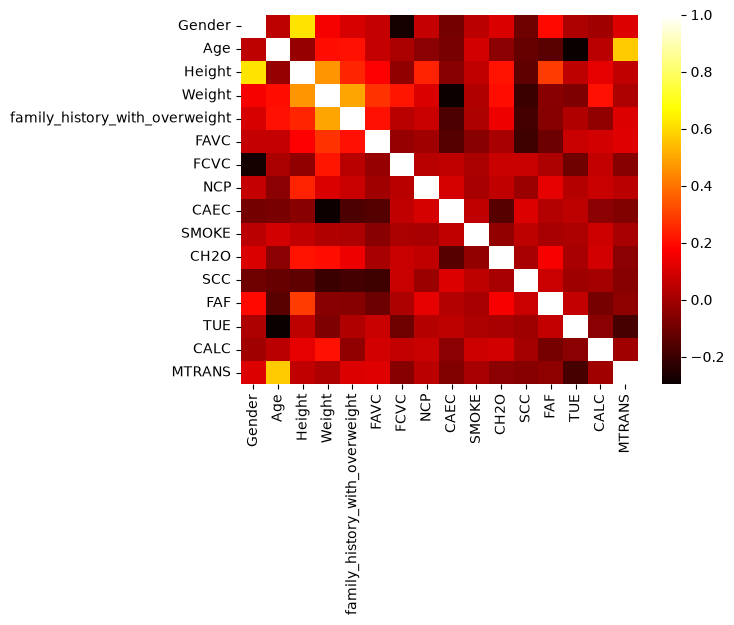

In [11]:
sns.heatmap(pcc, cmap='hot')

<Axes: >

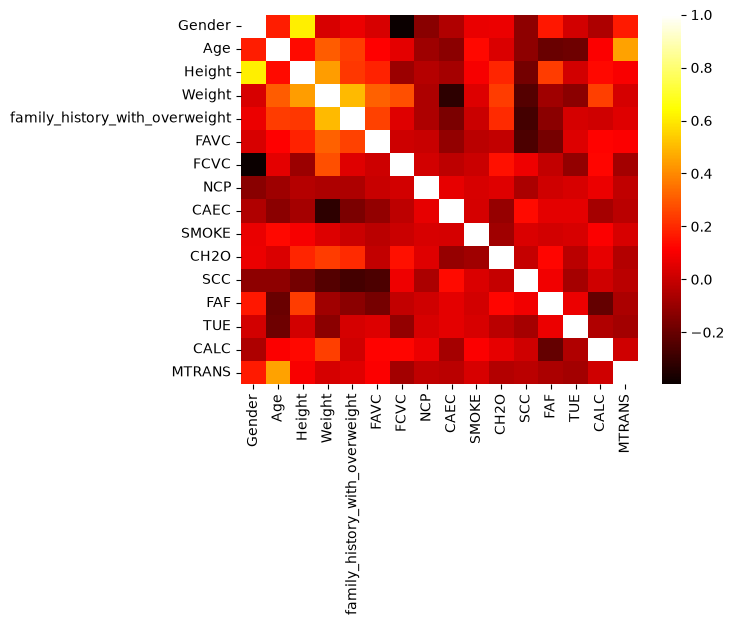

In [12]:
sns.heatmap(pcc_clean, cmap='hot')

### e. Cek Imbalance Data

1. Data Original

Jumlah data per kelas NObeyesdad:
NObeyesdad
4    351
6    324
5    297
2    290
3    290
1    287
0    272
Name: count, dtype: int64




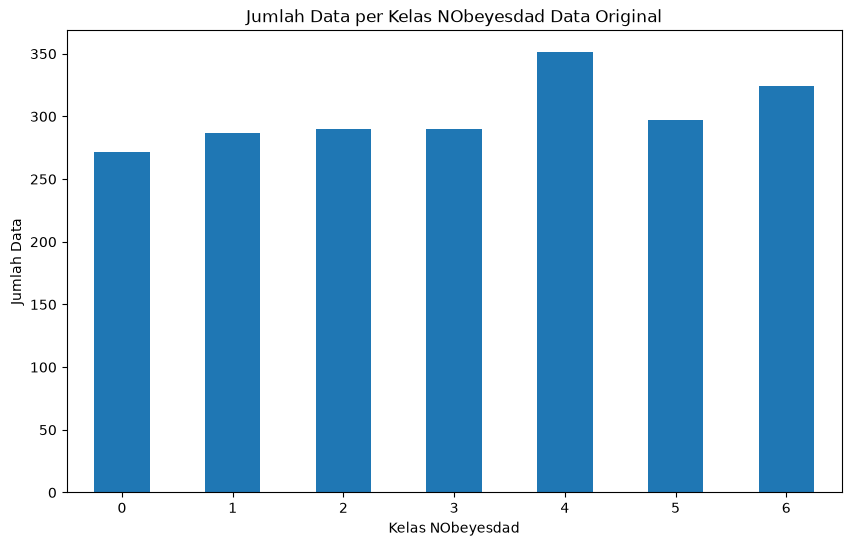

In [13]:
print("Jumlah data per kelas NObeyesdad:")
print(data['NObeyesdad'].value_counts())
print("\n")

# Diagram batang untuk jumlah data per kelas NObeyesdad
import matplotlib.pyplot as plt
data['NObeyesdad'].value_counts().sort_index().plot(kind='bar', figsize=(10,6))
plt.title('Jumlah Data per Kelas NObeyesdad Data Original')
plt.xlabel('Kelas NObeyesdad')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

2. Data Clean

Jumlah data per kelas NObeyesdad:
NObeyesdad
6    323
5    216
1    196
4    194
3    170
2    148
0    141
Name: count, dtype: int64




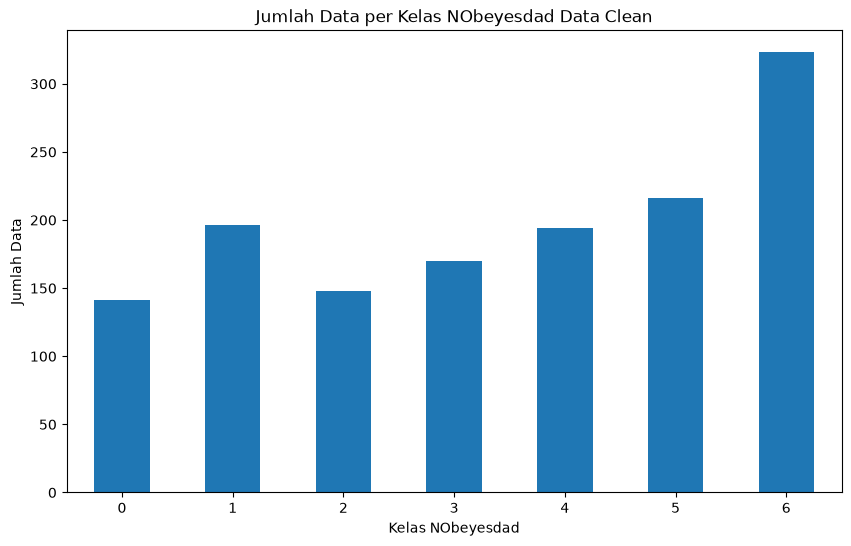

In [14]:
print("Jumlah data per kelas NObeyesdad:")
print(data_clean['NObeyesdad'].value_counts())
print("\n")

# Diagram batang untuk jumlah data per kelas NObeyesdad
import matplotlib.pyplot as plt
data_clean['NObeyesdad'].value_counts().sort_index().plot(kind='bar', figsize=(10,6))
plt.title('Jumlah Data per Kelas NObeyesdad Data Clean')
plt.xlabel('Kelas NObeyesdad')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

### f. Normalisasi

1. Data Original

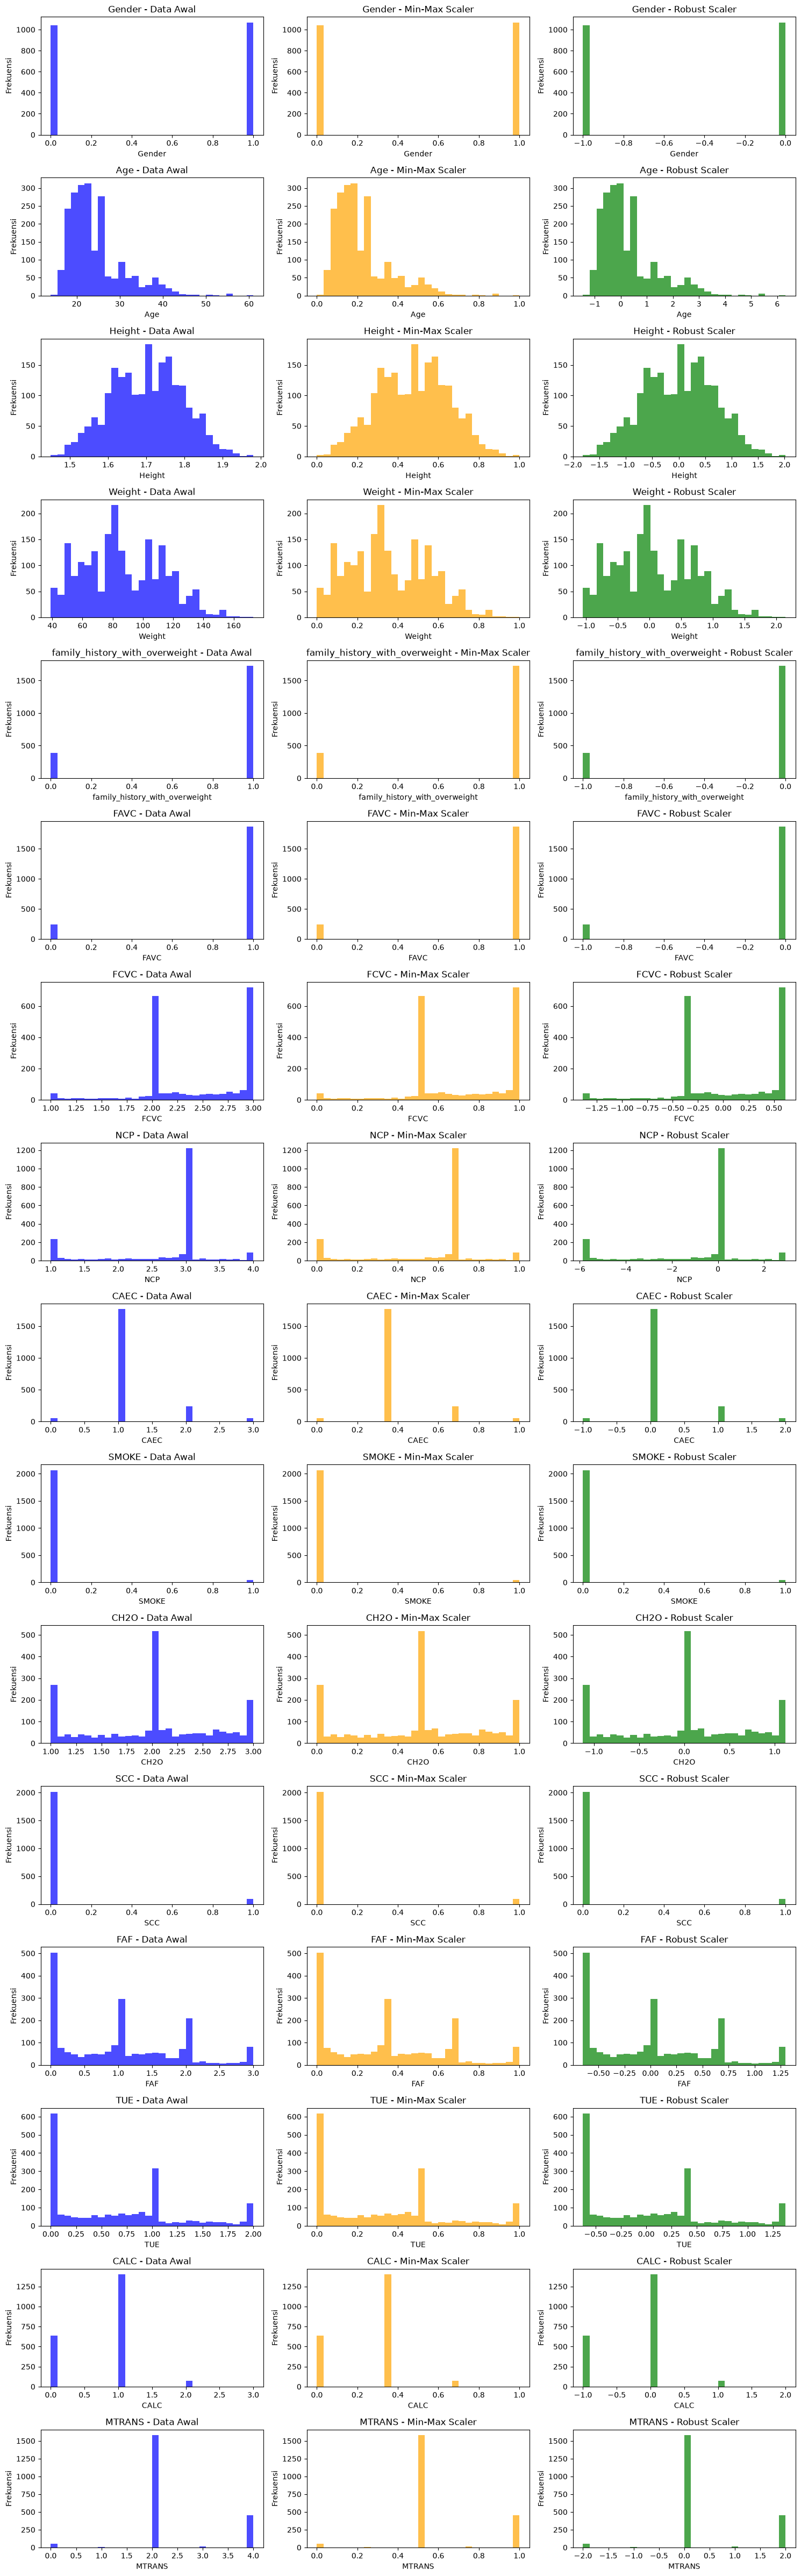

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0.0,0.148936,0.320755,0.186567,1.0,0.0,0.5,0.666667,0.333333,0.0,0.500000,0.0,0.000000,0.500000,0.000000,0.5,1
1,0.0,0.148936,0.132075,0.126866,1.0,0.0,1.0,0.666667,0.333333,1.0,1.000000,1.0,1.000000,0.000000,0.333333,0.5,1
2,1.0,0.191489,0.660377,0.283582,1.0,0.0,0.5,0.666667,0.333333,0.0,0.500000,0.0,0.666667,0.500000,0.666667,0.5,1
3,1.0,0.276596,0.660377,0.358209,0.0,0.0,1.0,0.666667,0.333333,0.0,0.500000,0.0,0.666667,0.000000,0.666667,0.0,2
4,1.0,0.170213,0.622642,0.379104,0.0,0.0,0.5,0.000000,0.333333,0.0,0.500000,0.0,0.000000,0.000000,0.333333,0.5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0.0,0.148443,0.491943,0.689616,1.0,1.0,1.0,0.666667,0.333333,0.0,0.364070,0.0,0.558756,0.453124,0.333333,0.5,6
2107,0.0,0.169850,0.563366,0.707037,1.0,1.0,1.0,0.666667,0.333333,0.0,0.502565,0.0,0.447130,0.299635,0.333333,0.5,6
2108,0.0,0.181362,0.570200,0.706637,1.0,1.0,1.0,0.666667,0.333333,0.0,0.527097,0.0,0.471403,0.323144,0.333333,0.5,6
2109,0.0,0.220467,0.546132,0.704079,1.0,1.0,1.0,0.666667,0.333333,0.0,0.926170,0.0,0.379702,0.293017,0.333333,0.5,6


In [15]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Pisahkan fitur dan target
X = data.drop('NObeyesdad', axis=1)
y = data['NObeyesdad']

# Simpan data awal untuk perbandingan
X_original = X.copy()

# Terapkan Min-Max Scaler
scaler_minmax = MinMaxScaler()
X_scaled_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), columns=X.columns)

# Terapkan Robust Scaler
scaler_robust = RobustScaler()
X_scaled_robust = pd.DataFrame(scaler_robust.fit_transform(X), columns=X.columns)

# Gabungkan kembali dengan Min-Max Scaler (untuk model training)
data_scaled = X_scaled_minmax.copy()
data_scaled['NObeyesdad'] = y

# Gabungkan kembali dengan Robust Scaler (untuk perbandingan)
data_scaled_robust = X_scaled_robust.copy()
data_scaled_robust['NObeyesdad'] = y

# Visualisasi perbandingan Min-Max vs Robust Scaler
features_to_plot = list(X.columns)


fig, axes = plt.subplots(len(features_to_plot), 3, figsize=(15, 48))

for i, feature in enumerate(features_to_plot):
    # Data awal
    axes[i, 0].hist(X_original[feature], bins=30, alpha=0.7, color='blue')
    axes[i, 0].set_title(f'{feature} - Data Awal')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Frekuensi')

    # Min-Max Scaler
    axes[i, 1].hist(X_scaled_minmax[feature], bins=30, alpha=0.7, color='orange')
    axes[i, 1].set_title(f'{feature} - Min-Max Scaler')
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel('Frekuensi')

    # Robust Scaler
    axes[i, 2].hist(X_scaled_robust[feature], bins=30, alpha=0.7, color='green')
    axes[i, 2].set_title(f'{feature} - Robust Scaler')
    axes[i, 2].set_xlabel(feature)
    axes[i, 2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

data_scaled

2. Data Clean

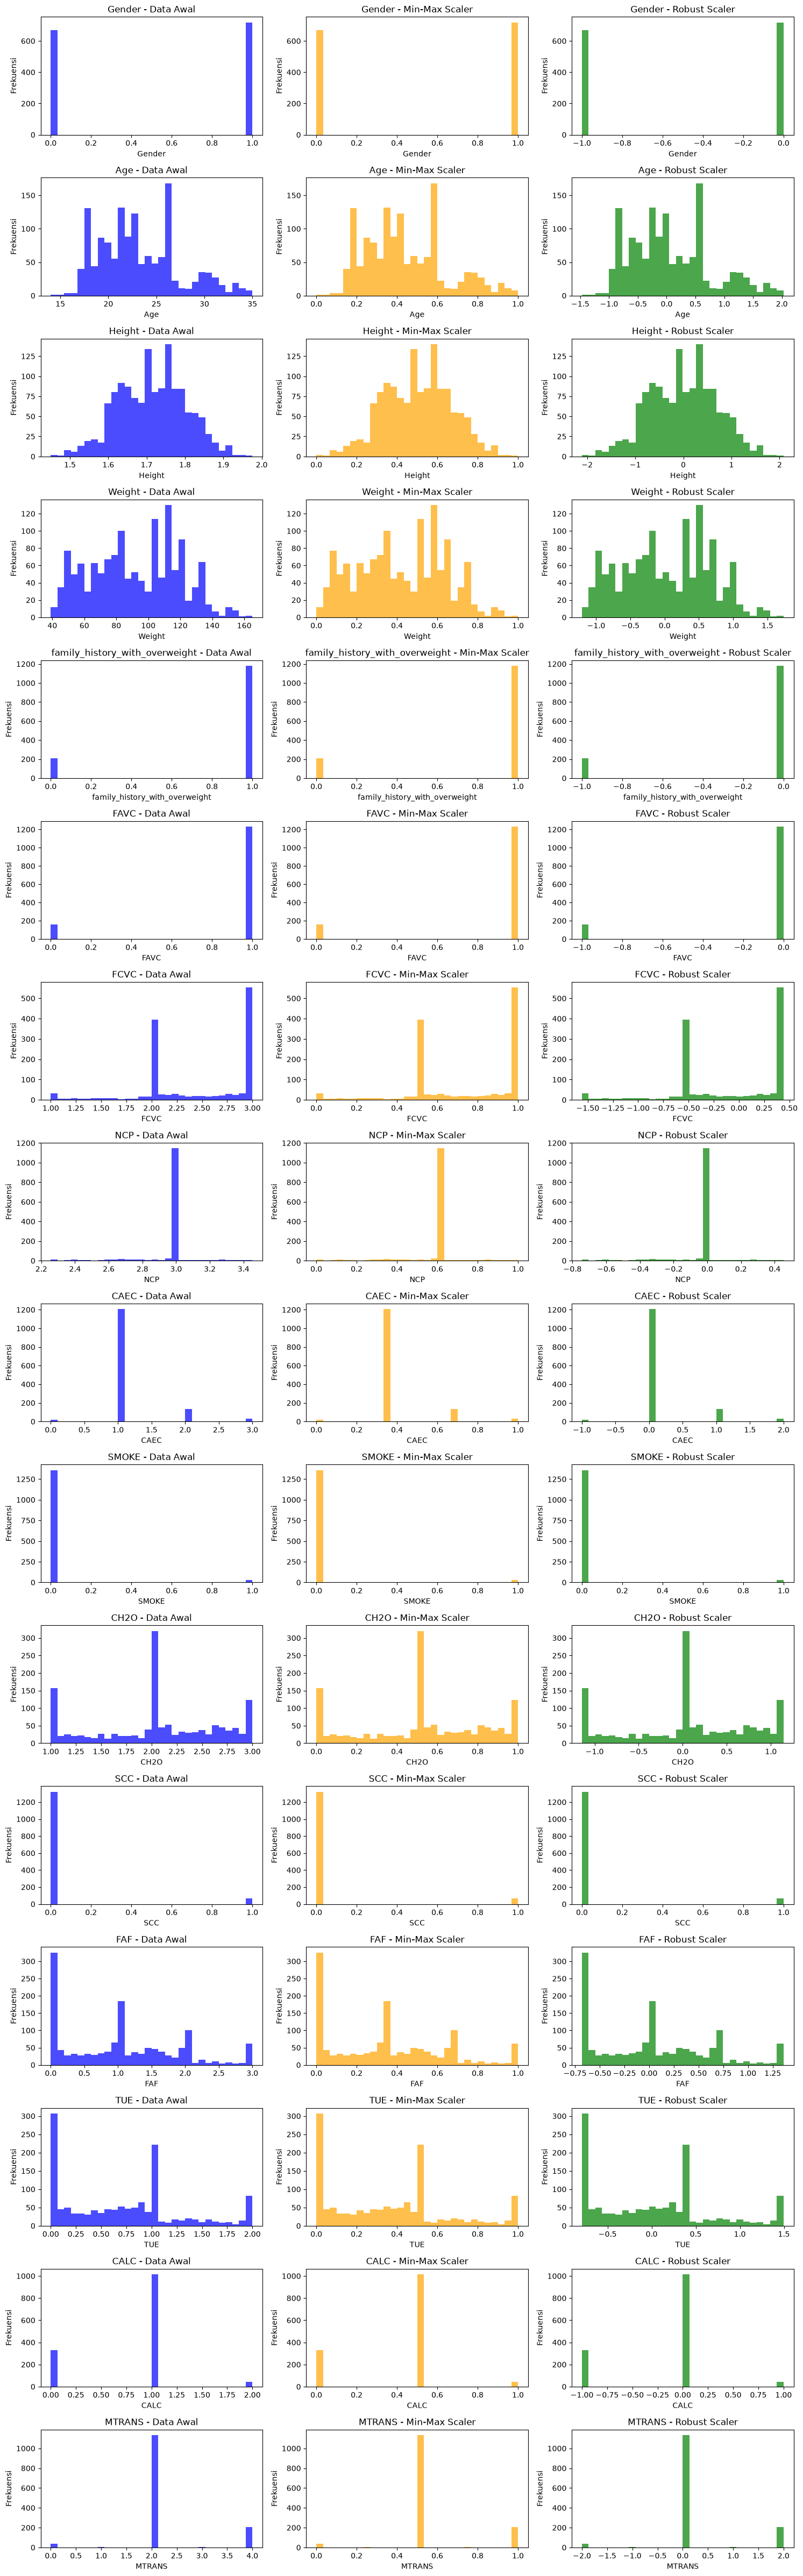

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0.0,0.333333,0.323401,0.198323,1.0,0.0,0.5,0.621729,0.333333,0.0,0.500000,0.0,0.000000,0.500000,0.0,0.5,1.0
1,0.0,0.333333,0.133165,0.134859,1.0,0.0,1.0,0.621729,0.333333,1.0,1.000000,1.0,1.000000,0.000000,0.5,0.5,1.0
2,1.0,0.428571,0.665826,0.301450,1.0,0.0,0.5,0.621729,0.333333,0.0,0.500000,0.0,0.666667,0.500000,1.0,0.5,1.0
3,1.0,0.619048,0.665826,0.380779,0.0,0.0,1.0,0.621729,0.333333,0.0,0.500000,0.0,0.666667,0.000000,1.0,0.0,2.0
4,1.0,0.714286,0.323401,0.111061,0.0,1.0,0.5,0.621729,0.333333,0.0,0.500000,0.0,0.000000,0.000000,0.5,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1383,0.0,0.332231,0.496002,0.733068,1.0,1.0,1.0,0.621729,0.333333,0.0,0.364070,0.0,0.558756,0.453124,0.5,0.5,NaN
1384,0.0,0.380140,0.568014,0.751587,1.0,1.0,1.0,0.621729,0.333333,0.0,0.502565,0.0,0.447130,0.299635,0.5,0.5,NaN
1385,0.0,0.405906,0.574904,0.751161,1.0,1.0,1.0,0.621729,0.333333,0.0,0.527097,0.0,0.471403,0.323144,0.5,0.5,NaN
1386,0.0,0.493426,0.550638,0.748443,1.0,1.0,1.0,0.621729,0.333333,0.0,0.926170,0.0,0.379702,0.293017,0.5,0.5,NaN


In [16]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Pisahkan fitur dan target
X_clean = data_clean.drop('NObeyesdad', axis=1)
y_clean = data_clean['NObeyesdad']

# Simpan data awal untuk perbandingan
X_clean = X_clean.copy()

# Terapkan Min-Max Scaler
scaler_minmax = MinMaxScaler()
X_clean_scaled_minmax = pd.DataFrame(scaler_minmax.fit_transform(X_clean), columns=X_clean.columns)

# Terapkan Robust Scaler
scaler_robust = RobustScaler()
X_clean_scaled_robust = pd.DataFrame(scaler_robust.fit_transform(X_clean), columns=X_clean.columns)

# Gabungkan kembali dengan Min-Max Scaler (untuk model training)
data_clean_scaled = X_clean_scaled_minmax.copy()
data_clean_scaled['NObeyesdad'] = y_clean

# Gabungkan kembali dengan Robust Scaler (untuk perbandingan)
data_clean_scaled_robust = X_clean_scaled_robust.copy()
data_clean_scaled_robust['NObeyesdad'] = y_clean

# Visualisasi perbandingan Min-Max vs Robust Scaler
features_to_plot = list(X_clean.columns)


fig, axes = plt.subplots(len(features_to_plot), 3, figsize=(15, 48))

for i, feature in enumerate(features_to_plot):
    # Data awal
    axes[i, 0].hist(X_clean[feature], bins=30, alpha=0.7, color='blue')
    axes[i, 0].set_title(f'{feature} - Data Awal')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Frekuensi')

    # Min-Max Scaler
    axes[i, 1].hist(X_clean_scaled_minmax[feature], bins=30, alpha=0.7, color='orange')
    axes[i, 1].set_title(f'{feature} - Min-Max Scaler')
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel('Frekuensi')

    # Robust Scaler
    axes[i, 2].hist(X_clean_scaled_robust[feature], bins=30, alpha=0.7, color='green')
    axes[i, 2].set_title(f'{feature} - Robust Scaler')
    axes[i, 2].set_xlabel(feature)
    axes[i, 2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

data_clean_scaled

# **3. Model**

## 1) Data Original

### a. Train Test Split

In [17]:
X_ori = data.drop('NObeyesdad', axis=1)
y_ori = data['NObeyesdad']

X_ori_train, X_ori_test, y_ori_train, y_ori_test = train_test_split(
    X_ori, y_ori, test_size=0.2, random_state=42, stratify=y_ori
)

scaler = MinMaxScaler()

X_ori_train_scaled = scaler.fit_transform(X_ori_train)
X_ori_test_scaled = scaler.transform(X_ori_test)

### b. Undersampling dan Oversampling

Distribusi Original:
NObeyesdad
0    218
1    229
2    232
3    232
4    281
5    237
6    259
Name: count, dtype: int64

Distribusi Undersampling:
NObeyesdad
0    218
1    218
2    218
3    218
4    218
5    218
6    218
Name: count, dtype: int64

Distribusi SMOTE:
NObeyesdad
0    281
1    281
2    281
3    281
4    281
5    281
6    281
Name: count, dtype: int64


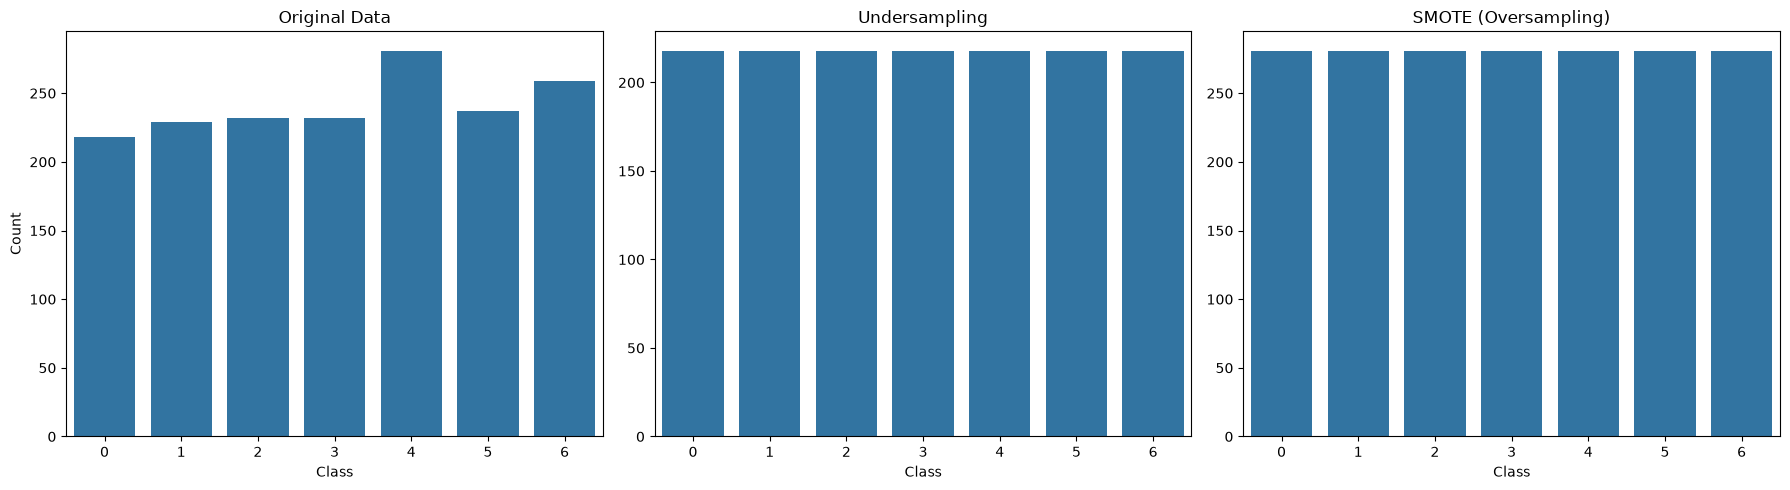

In [18]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# undersampling
rus_ori = RandomUnderSampler(random_state=42)
X_ori_under, y_ori_under = rus_ori.fit_resample(X_ori_train_scaled, y_ori_train)

#oversampling
smote = SMOTE(random_state=42)
X_ori_over, y_ori_over = smote.fit_resample(X_ori_train_scaled, y_ori_train)

print("Distribusi Original:")
print(y_ori_train.value_counts().sort_index())

print("\nDistribusi Undersampling:")
print(y_ori_under.value_counts().sort_index())

print("\nDistribusi SMOTE:")
print(y_ori_over.value_counts().sort_index())

# Hitung distribusi
dist_ori = y_ori_train.value_counts().sort_index()
dist_under = y_ori_under.value_counts().sort_index()
dist_over = y_ori_over.value_counts().sort_index()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(x=dist_ori.index, y=dist_ori.values, ax=axes[0])
axes[0].set_title("Original Data")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

sns.barplot(x=dist_under.index, y=dist_under.values, ax=axes[1])
axes[1].set_title("Undersampling")
axes[1].set_xlabel("Class")

sns.barplot(x=dist_over.index, y=dist_over.values, ax=axes[2])
axes[2].set_title("SMOTE (Oversampling)")
axes[2].set_xlabel("Class")

plt.tight_layout()
plt.show()

### c. Pembuatan dan Evaluasi Model KNN

DATASET : Original

BASELINE KNN
Accuracy          : 0.7896
Precision (Macro) : 0.7837
Recall (Macro)    : 0.7862
F1 Score (Macro)  : 0.7804
Balanced Accuracy : 0.7862


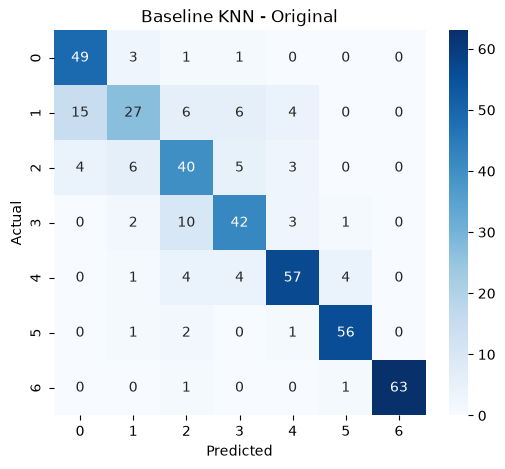


OPTIMIZED KNN
Best Parameter : {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score  : 0.7802093187053526
Accuracy          : 0.8180
Precision (Macro) : 0.8114
Recall (Macro)    : 0.8148
F1 Score (Macro)  : 0.8090
Balanced Accuracy : 0.8148


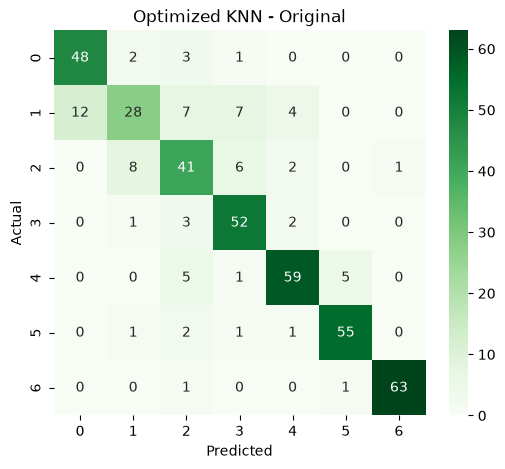

DATASET : Undersampling

BASELINE KNN
Accuracy          : 0.7612
Precision (Macro) : 0.7564
Recall (Macro)    : 0.7592
F1 Score (Macro)  : 0.7509
Balanced Accuracy : 0.7592


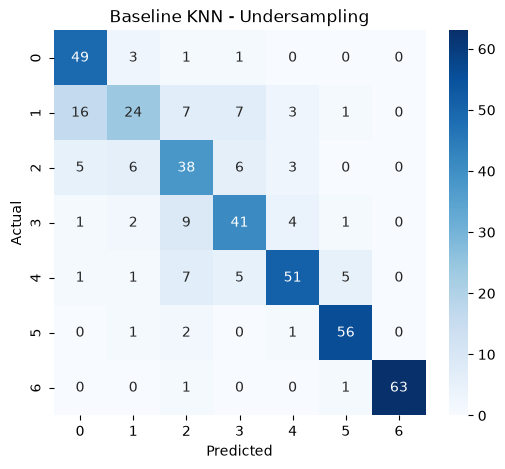


OPTIMIZED KNN
Best Parameter : {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score  : 0.7714194956184338
Accuracy          : 0.8085
Precision (Macro) : 0.8031
Recall (Macro)    : 0.8054
F1 Score (Macro)  : 0.7995
Balanced Accuracy : 0.8054


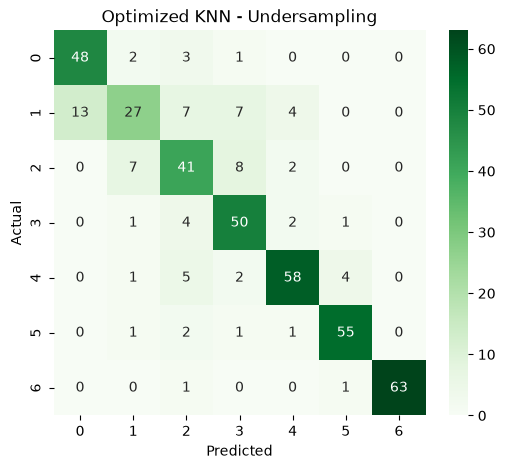

DATASET : SMOTE

BASELINE KNN
Accuracy          : 0.7896
Precision (Macro) : 0.7820
Recall (Macro)    : 0.7863
F1 Score (Macro)  : 0.7806
Balanced Accuracy : 0.7863


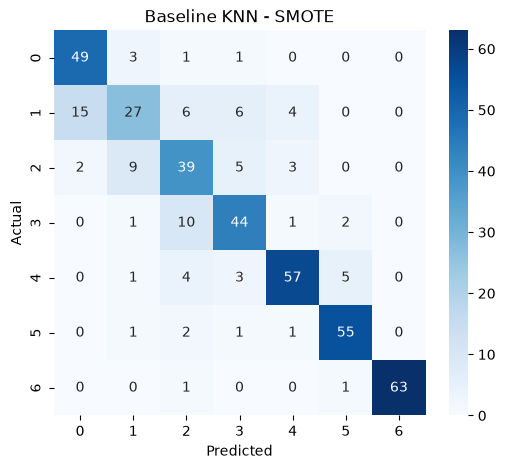


OPTIMIZED KNN
Best Parameter : {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score  : 0.8381029194711529
Accuracy          : 0.8180
Precision (Macro) : 0.8136
Recall (Macro)    : 0.8154
F1 Score (Macro)  : 0.8082
Balanced Accuracy : 0.8154


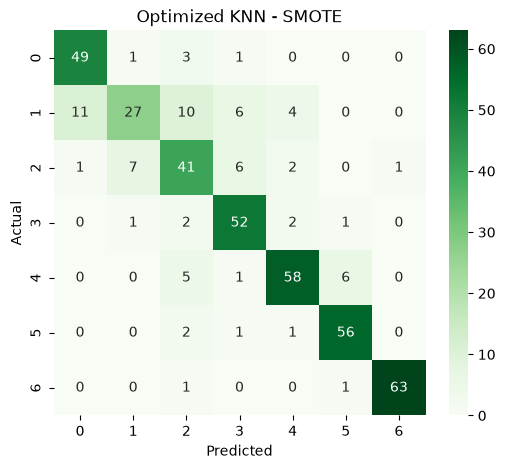



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Original,Baseline,0.789598,0.783741,0.786224,0.780381,0.786224
1,Original,Optimized,0.817967,0.811380,0.814836,0.809025,0.814836
2,Undersampling,Baseline,0.761229,0.756391,0.759201,0.750881,0.759201
3,Undersampling,Optimized,0.808511,0.803134,0.805406,0.799536,0.805406
4,SMOTE,Baseline,0.789598,0.782045,0.786306,0.780568,0.786306
5,SMOTE,Optimized,0.817967,0.813581,0.815358,0.808208,0.815358


In [19]:
datasets = {
    "Original": (X_ori_train_scaled, y_ori_train),
    "Undersampling": (X_ori_under, y_ori_under),
    "SMOTE": (X_ori_over, y_ori_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE KNN")

    baseline_knn = KNeighborsClassifier()

    baseline_knn.fit(X_train, y_train)

    baseline_pred = baseline_knn.predict(X_ori_test_scaled)

    baseline_accuracy = accuracy_score(
        y_ori_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_ori_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline KNN - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED KNN")

    param_grid_knn = {
        'n_neighbors': [3,5,7,9],
        'weights': ['uniform','distance']
    }

    grid_knn = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid_knn,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_knn.fit(
        X_train,
        y_train
    )

    best_knn = grid_knn.best_estimator_

    print("Best Parameter :", grid_knn.best_params_)
    print("Best CV Score  :", grid_knn.best_score_)

    y_pred = best_knn.predict(
        X_ori_test_scaled
    )

    accuracy = accuracy_score(
        y_ori_test,
        y_pred
    )

    precision = precision_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_ori_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized KNN - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

### d. Pembuatan dan Evaluasi Model Decision Tree

DATASET : Original

BASELINE Decision Tree
Accuracy          : 0.9267
Precision (Macro) : 0.9283
Recall (Macro)    : 0.9228
F1 Score (Macro)  : 0.9246
Balanced Accuracy : 0.9228


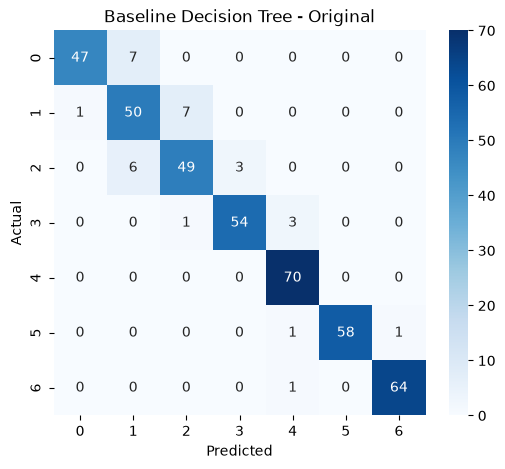


OPTIMIZED Decision Tree
Best Parameter : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Score  : 0.925870331935202
Accuracy          : 0.9196
Precision (Macro) : 0.9213
Recall (Macro)    : 0.9154
F1 Score (Macro)  : 0.9171
Balanced Accuracy : 0.9154


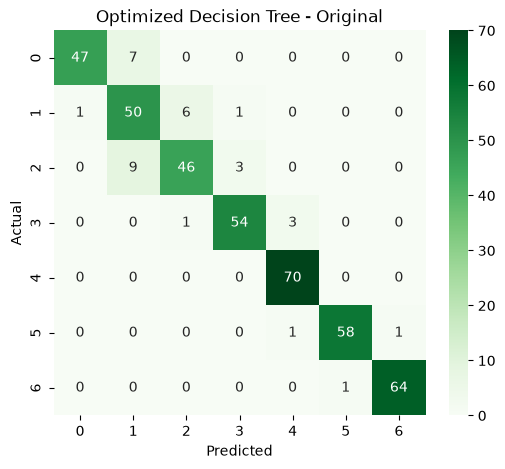

DATASET : Undersampling

BASELINE Decision Tree
Accuracy          : 0.9173
Precision (Macro) : 0.9167
Recall (Macro)    : 0.9140
F1 Score (Macro)  : 0.9146
Balanced Accuracy : 0.9140


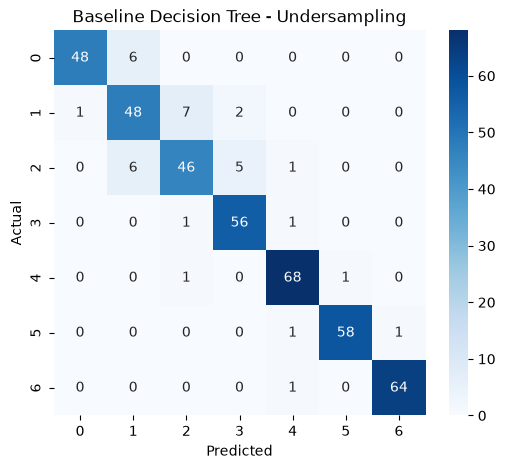


OPTIMIZED Decision Tree
Best Parameter : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Score  : 0.9271394602393512
Accuracy          : 0.9102
Precision (Macro) : 0.9083
Recall (Macro)    : 0.9070
F1 Score (Macro)  : 0.9074
Balanced Accuracy : 0.9070


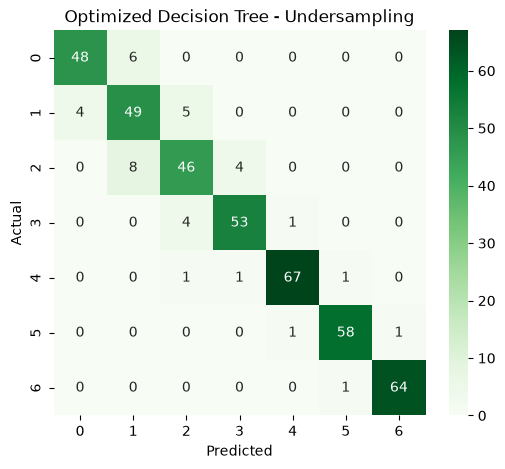

DATASET : SMOTE

BASELINE Decision Tree
Accuracy          : 0.9149
Precision (Macro) : 0.9160
Recall (Macro)    : 0.9110
F1 Score (Macro)  : 0.9128
Balanced Accuracy : 0.9110


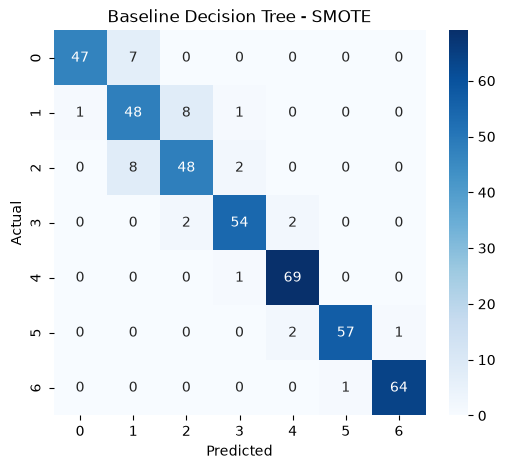


OPTIMIZED Decision Tree
Best Parameter : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score  : 0.9364231220039307
Accuracy          : 0.9149
Precision (Macro) : 0.9160
Recall (Macro)    : 0.9110
F1 Score (Macro)  : 0.9128
Balanced Accuracy : 0.9110


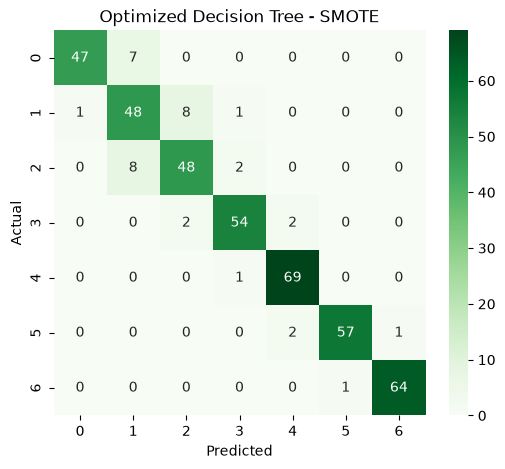



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Original,Baseline,0.926714,0.928255,0.922798,0.924643,0.922798
1,Original,Optimized,0.919622,0.921331,0.915408,0.917073,0.915408
2,Undersampling,Baseline,0.917258,0.916708,0.913972,0.914647,0.913972
3,Undersampling,Optimized,0.910165,0.908339,0.907005,0.907386,0.907005
4,SMOTE,Baseline,0.914894,0.916039,0.910987,0.912761,0.910987
5,SMOTE,Optimized,0.914894,0.916039,0.910987,0.912761,0.910987


In [20]:
datasets = {
    "Original": (X_ori_train_scaled, y_ori_train),
    "Undersampling": (X_ori_under, y_ori_under),
    "SMOTE": (X_ori_over, y_ori_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE Decision Tree")

    baseline_dt = DecisionTreeClassifier(random_state=42)

    baseline_dt.fit(X_train, y_train)

    baseline_pred = baseline_dt.predict(X_ori_test_scaled)

    baseline_accuracy = accuracy_score(
        y_ori_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_ori_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline Decision Tree - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED Decision Tree")

    param_grid_dt = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2,5,10],
        'min_samples_leaf': [1, 2, 4]
    }

    grid_dt = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid_dt,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_dt.fit(
        X_train,
        y_train
    )

    best_dt = grid_dt.best_estimator_

    print("Best Parameter :", grid_dt.best_params_)
    print("Best CV Score  :", grid_dt.best_score_)

    y_pred = best_dt.predict(
        X_ori_test_scaled
    )

    accuracy = accuracy_score(
        y_ori_test,
        y_pred
    )

    precision = precision_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_ori_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized Decision Tree - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

### e. Pembuatan dan Evaluasi Model Naive Bayes

DATASET : Original

BASELINE Naive Bayes
Accuracy          : 0.6123
Precision (Macro) : 0.6540
Recall (Macro)    : 0.6095
F1 Score (Macro)  : 0.5952
Balanced Accuracy : 0.6095


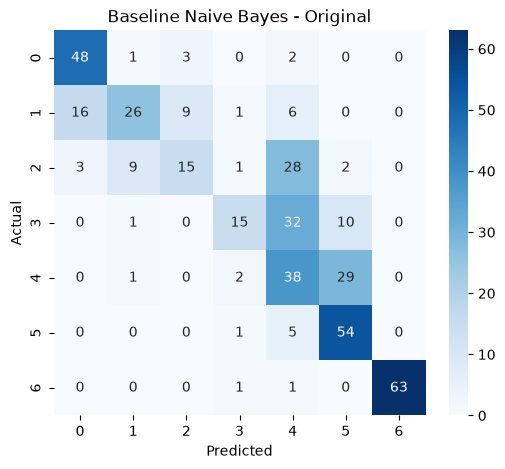


OPTIMIZED Naive Bayes
Best Parameter : {'var_smoothing': 1e-05}
Best CV Score  : 0.5837798487217903
Accuracy          : 0.6123
Precision (Macro) : 0.6540
Recall (Macro)    : 0.6095
F1 Score (Macro)  : 0.5952
Balanced Accuracy : 0.6095


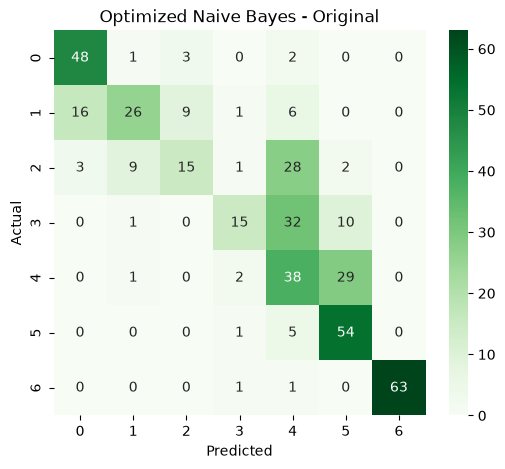

DATASET : Undersampling

BASELINE Naive Bayes
Accuracy          : 0.6123
Precision (Macro) : 0.6446
Recall (Macro)    : 0.6093
F1 Score (Macro)  : 0.5937
Balanced Accuracy : 0.6093


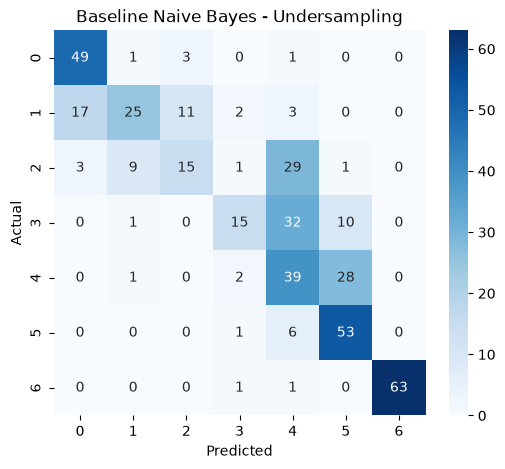


OPTIMIZED Naive Bayes
Best Parameter : {'var_smoothing': 1e-05}
Best CV Score  : 0.5705412630338059
Accuracy          : 0.6123
Precision (Macro) : 0.6446
Recall (Macro)    : 0.6093
F1 Score (Macro)  : 0.5937
Balanced Accuracy : 0.6093


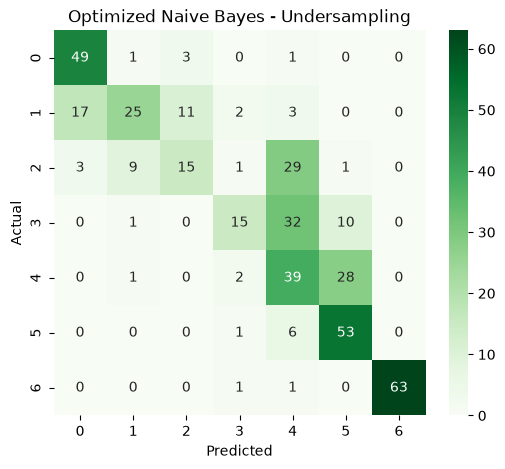

DATASET : SMOTE

BASELINE Naive Bayes
Accuracy          : 0.6147
Precision (Macro) : 0.6570
Recall (Macro)    : 0.6122
F1 Score (Macro)  : 0.5933
Balanced Accuracy : 0.6122


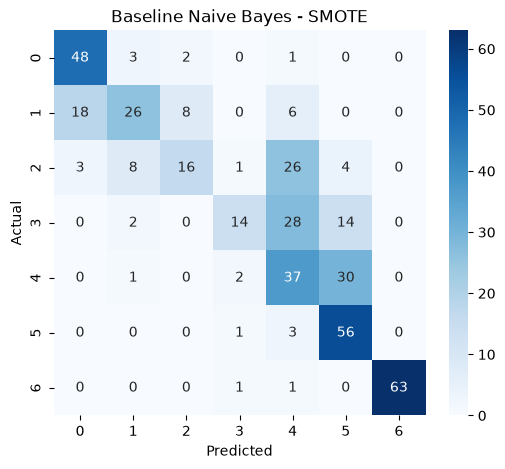


OPTIMIZED Naive Bayes
Best Parameter : {'var_smoothing': 1e-05}
Best CV Score  : 0.5698126270132438
Accuracy          : 0.6147
Precision (Macro) : 0.6570
Recall (Macro)    : 0.6122
F1 Score (Macro)  : 0.5933
Balanced Accuracy : 0.6122


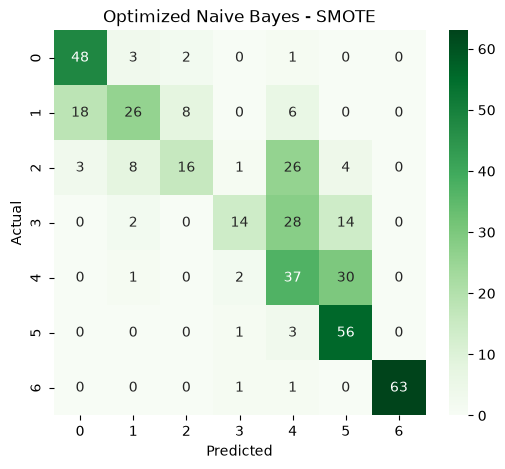



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Original,Baseline,0.612293,0.654025,0.609499,0.595211,0.609499
1,Original,Optimized,0.612293,0.654025,0.609499,0.595211,0.609499
2,Undersampling,Baseline,0.612293,0.644617,0.609341,0.593653,0.609341
3,Undersampling,Optimized,0.612293,0.644617,0.609341,0.593653,0.609341
4,SMOTE,Baseline,0.614657,0.657012,0.612220,0.593318,0.612220
5,SMOTE,Optimized,0.614657,0.657012,0.612220,0.593318,0.612220


In [21]:
datasets = {
    "Original": (X_ori_train_scaled, y_ori_train),
    "Undersampling": (X_ori_under, y_ori_under),
    "SMOTE": (X_ori_over, y_ori_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE Naive Bayes")

    baseline_nb = GaussianNB()

    baseline_nb.fit(X_train, y_train)

    baseline_pred = baseline_nb.predict(X_ori_test_scaled)

    baseline_accuracy = accuracy_score(
        y_ori_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_ori_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline Naive Bayes - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED Naive Bayes")

    param_grid_nb = {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    }

    grid_nb = GridSearchCV(
        estimator=GaussianNB(),
        param_grid=param_grid_nb,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_nb.fit(
        X_train,
        y_train
    )

    best_nb = grid_nb.best_estimator_

    print("Best Parameter :", grid_nb.best_params_)
    print("Best CV Score  :", grid_nb.best_score_)

    y_pred = best_nb.predict(
        X_ori_test_scaled
    )

    accuracy = accuracy_score(
        y_ori_test,
        y_pred
    )

    precision = precision_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_ori_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized Naive Bayes - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

### f. Pembuatan dan Evaluasi Model Random Forest

DATASET : Original

BASELINE RF
Accuracy          : 0.9480
Precision (Macro) : 0.9528
Recall (Macro)    : 0.9459
F1 Score (Macro)  : 0.9473
Balanced Accuracy : 0.9459


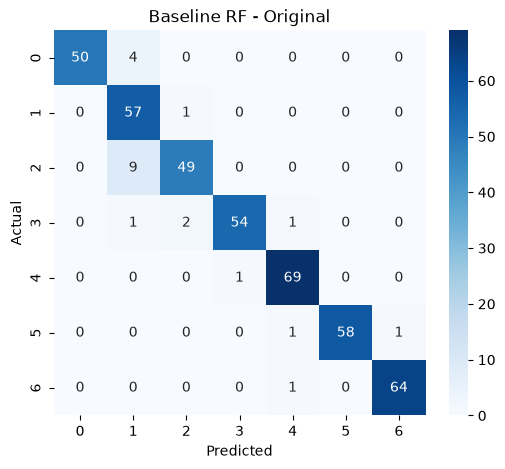


OPTIMIZED RF
Best Parameter : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Score  : 0.951405838654968
Accuracy          : 0.9480
Precision (Macro) : 0.9533
Recall (Macro)    : 0.9459
F1 Score (Macro)  : 0.9472
Balanced Accuracy : 0.9459


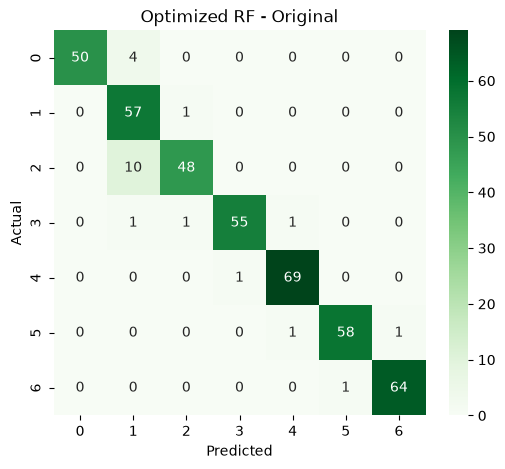

DATASET : Undersampling

BASELINE RF
Accuracy          : 0.9433
Precision (Macro) : 0.9479
Recall (Macro)    : 0.9420
F1 Score (Macro)  : 0.9427
Balanced Accuracy : 0.9420


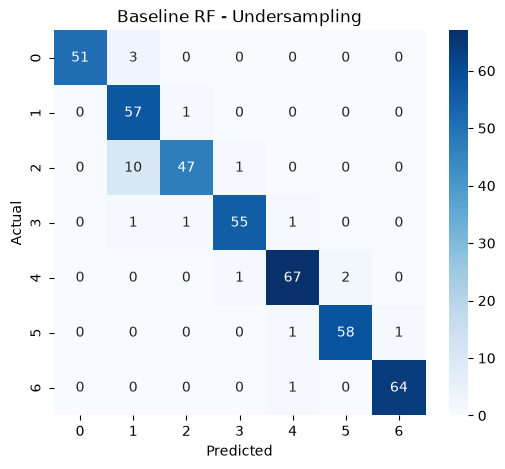


OPTIMIZED RF
Best Parameter : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score  : 0.9540186295824278
Accuracy          : 0.9362
Precision (Macro) : 0.9411
Recall (Macro)    : 0.9345
F1 Score (Macro)  : 0.9353
Balanced Accuracy : 0.9345


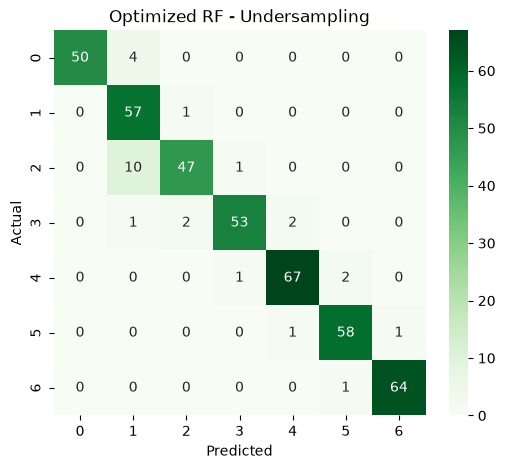

DATASET : SMOTE

BASELINE RF
Accuracy          : 0.9433
Precision (Macro) : 0.9477
Recall (Macro)    : 0.9410
F1 Score (Macro)  : 0.9426
Balanced Accuracy : 0.9410


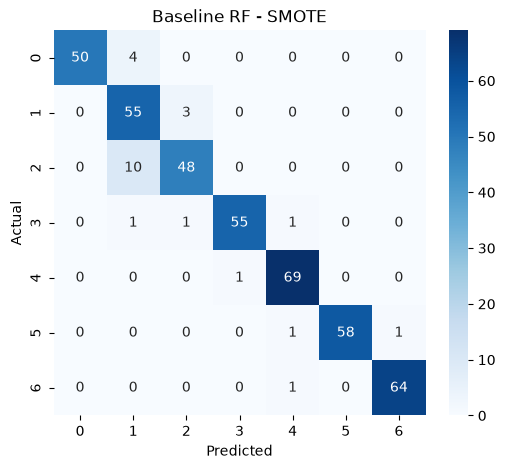


OPTIMIZED RF
Best Parameter : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score  : 0.9626763417476102
Accuracy          : 0.9433
Precision (Macro) : 0.9465
Recall (Macro)    : 0.9412
F1 Score (Macro)  : 0.9420
Balanced Accuracy : 0.9412


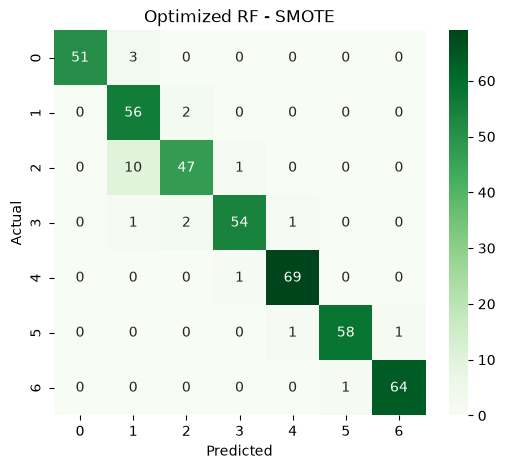



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Original,Baseline,0.947991,0.952842,0.945935,0.947345,0.945935
1,Original,Optimized,0.947991,0.953330,0.945935,0.947199,0.945935
2,Undersampling,Baseline,0.943262,0.947905,0.942036,0.942657,0.942036
3,Undersampling,Optimized,0.936170,0.941126,0.934464,0.935332,0.934464
4,SMOTE,Baseline,0.943262,0.947698,0.941009,0.942579,0.941009
5,SMOTE,Optimized,0.943262,0.946479,0.941191,0.942044,0.941191


In [22]:
datasets = {
    "Original": (X_ori_train_scaled, y_ori_train),
    "Undersampling": (X_ori_under, y_ori_under),
    "SMOTE": (X_ori_over, y_ori_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE RF")

    baseline_rf = RandomForestClassifier(random_state=42)

    baseline_rf.fit(X_train, y_train)

    baseline_pred = baseline_rf.predict(X_ori_test_scaled)

    baseline_accuracy = accuracy_score(
        y_ori_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_ori_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline RF - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED RF")

    param_grid_rf = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    grid_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid_rf,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_rf.fit(
        X_train,
        y_train
    )

    best_rf = grid_rf.best_estimator_

    print("Best Parameter :", grid_rf.best_params_)
    print("Best CV Score  :", grid_rf.best_score_)

    y_pred = best_rf.predict(
        X_ori_test_scaled
    )

    accuracy = accuracy_score(
        y_ori_test,
        y_pred
    )

    precision = precision_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_ori_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized RF - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

### g. Pembuatan dan Evaluasi Model SVM

DATASET : Original

BASELINE SVM
Accuracy          : 0.8203
Precision (Macro) : 0.8163
Recall (Macro)    : 0.8183
F1 Score (Macro)  : 0.8165
Balanced Accuracy : 0.8183


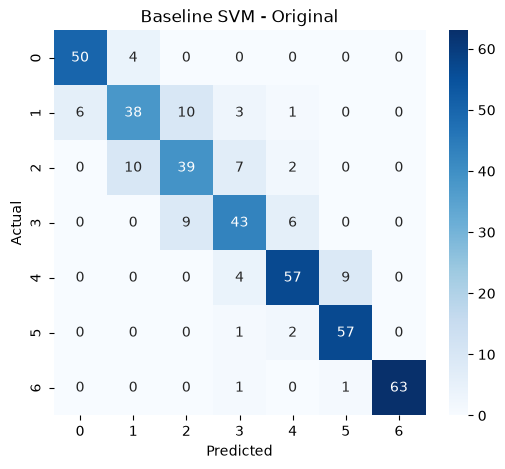


OPTIMIZED SVM
Best Parameter : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.9629350440290827
Accuracy          : 0.9504
Precision (Macro) : 0.9505
Recall (Macro)    : 0.9493
F1 Score (Macro)  : 0.9493
Balanced Accuracy : 0.9493


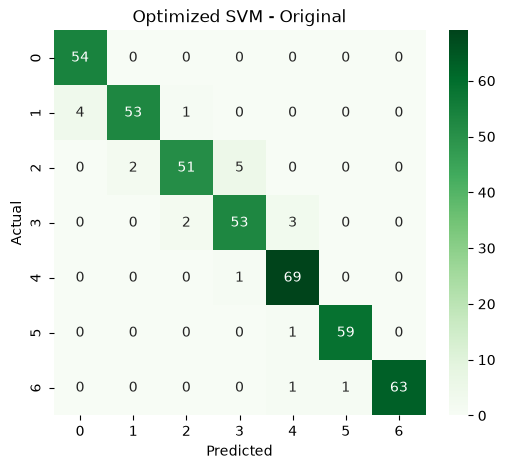

DATASET : Undersampling

BASELINE SVM
Accuracy          : 0.8109
Precision (Macro) : 0.8071
Recall (Macro)    : 0.8098
F1 Score (Macro)  : 0.8072
Balanced Accuracy : 0.8098


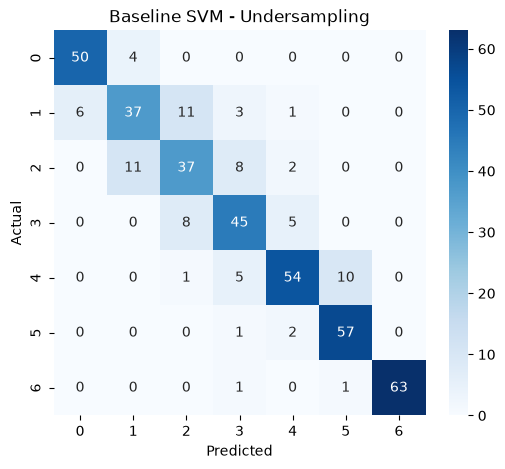


OPTIMIZED SVM
Best Parameter : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.9559908348487424
Accuracy          : 0.9527
Precision (Macro) : 0.9520
Recall (Macro)    : 0.9518
F1 Score (Macro)  : 0.9513
Balanced Accuracy : 0.9518


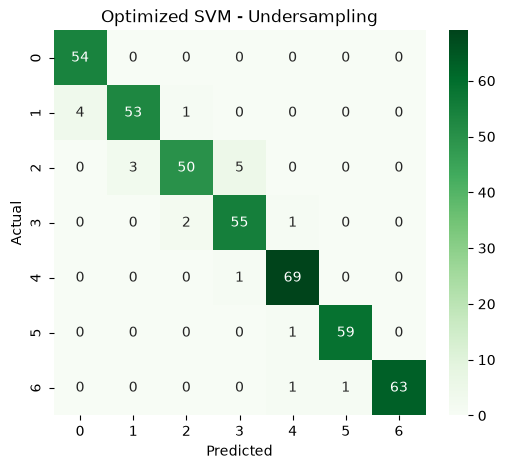

DATASET : SMOTE

BASELINE SVM
Accuracy          : 0.8227
Precision (Macro) : 0.8201
Recall (Macro)    : 0.8217
F1 Score (Macro)  : 0.8198
Balanced Accuracy : 0.8217


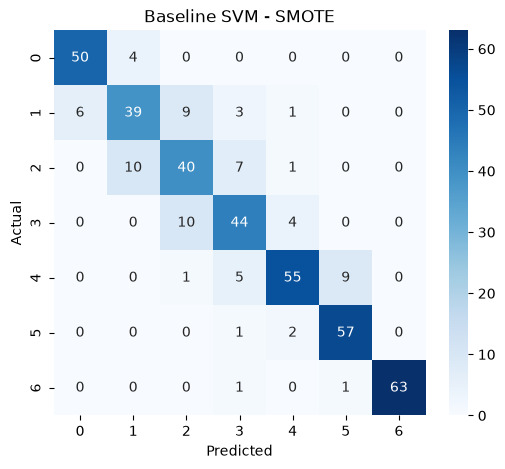


OPTIMIZED SVM
Best Parameter : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.9633219915145416
Accuracy          : 0.9551
Precision (Macro) : 0.9559
Recall (Macro)    : 0.9542
F1 Score (Macro)  : 0.9544
Balanced Accuracy : 0.9542


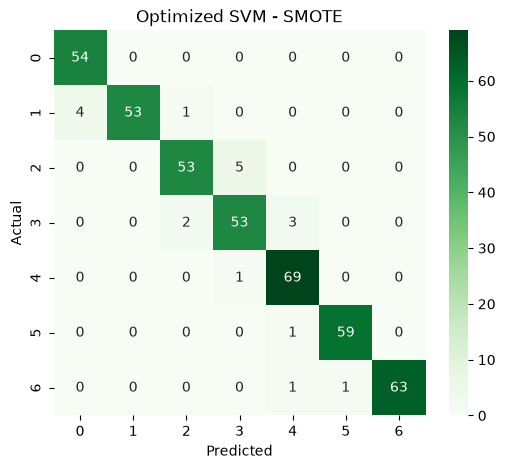



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Original,Baseline,0.820331,0.816262,0.818344,0.816508,0.818344
1,Original,Optimized,0.950355,0.950455,0.949311,0.949297,0.949311
2,Undersampling,Baseline,0.810875,0.807113,0.809758,0.807153,0.809758
3,Undersampling,Optimized,0.952719,0.952024,0.951774,0.951274,0.951774
4,SMOTE,Baseline,0.822695,0.820064,0.821652,0.819762,0.821652
5,SMOTE,Optimized,0.955083,0.955933,0.954237,0.954441,0.954237


In [23]:
datasets = {
    "Original": (X_ori_train_scaled, y_ori_train),
    "Undersampling": (X_ori_under, y_ori_under),
    "SMOTE": (X_ori_over, y_ori_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE SVM")

    baseline_svm = SVC(random_state=42)

    baseline_svm.fit(X_train, y_train)

    baseline_pred = baseline_svm.predict(X_ori_test_scaled)

    baseline_accuracy = accuracy_score(
        y_ori_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_ori_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_ori_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline SVM - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED SVM")

    param_grid_svm = {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    }

    grid_svm = GridSearchCV(
        estimator=SVC(random_state=42),
        param_grid=param_grid_svm,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_svm.fit(
        X_train,
        y_train
    )

    best_svm = grid_svm.best_estimator_

    print("Best Parameter :", grid_svm.best_params_)
    print("Best CV Score  :", grid_svm.best_score_)

    y_pred = best_svm.predict(
        X_ori_test_scaled
    )

    accuracy = accuracy_score(
        y_ori_test,
        y_pred
    )

    precision = precision_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_ori_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_ori_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_ori_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized SVM - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

## 2) Data Setelah Cleaning

### a. Train Test Split

In [24]:
X_clean = data_clean.drop('NObeyesdad', axis=1)
y_clean = data_clean['NObeyesdad']

X_clean_train, X_clean_test, y_clean_train, y_clean_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

scaler_clean = MinMaxScaler()

X_clean_train_scaled = scaler_clean.fit_transform(X_clean_train)
X_clean_test_scaled = scaler_clean.transform(X_clean_test)

### b. Undersampling dan Oversampling

Distribusi Original:
NObeyesdad
0    113
1    157
2    118
3    136
4    155
5    173
6    258
Name: count, dtype: int64

Distribusi Undersampling:
NObeyesdad
0    113
1    113
2    113
3    113
4    113
5    113
6    113
Name: count, dtype: int64

Distribusi SMOTE:
NObeyesdad
0    258
1    258
2    258
3    258
4    258
5    258
6    258
Name: count, dtype: int64


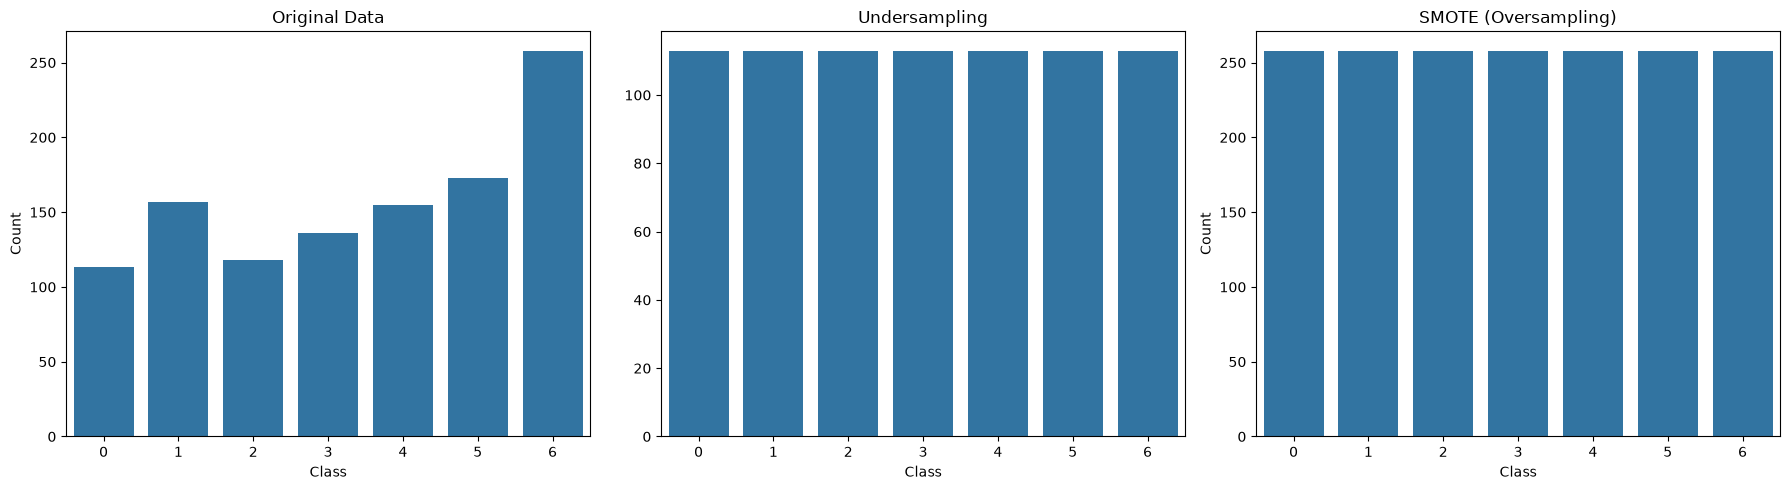

In [25]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# undersampling
rus_clean = RandomUnderSampler(random_state=42)
X_clean_under, y_clean_under = rus_clean.fit_resample(X_clean_train_scaled, y_clean_train)

#oversampling
smote = SMOTE(random_state=42)
X_clean_over, y_clean_over = smote.fit_resample(X_clean_train_scaled, y_clean_train)

print("Distribusi Original:")
print(y_clean_train.value_counts().sort_index())

print("\nDistribusi Undersampling:")
print(y_clean_under.value_counts().sort_index())

print("\nDistribusi SMOTE:")
print(y_clean_over.value_counts().sort_index())

# Hitung distribusi
dist_ori = y_clean_train.value_counts().sort_index()
dist_under = y_clean_under.value_counts().sort_index()
dist_over = y_clean_over.value_counts().sort_index()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(x=dist_ori.index, y=dist_ori.values, ax=axes[0])
axes[0].set_title("Original Data")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

sns.barplot(x=dist_under.index, y=dist_under.values, ax=axes[1])
axes[1].set_title("Undersampling")
axes[1].set_xlabel("Class")

sns.barplot(x=dist_over.index, y=dist_over.values, ax=axes[2])
axes[2].set_title("SMOTE (Oversampling)")
axes[2].set_xlabel("Class")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

### c. Pembuatan dan Evaluasi Model KNN

DATASET : Cleaning

BASELINE KNN
Accuracy          : 0.7626
Precision (Macro) : 0.7273
Recall (Macro)    : 0.7317
F1 Score (Macro)  : 0.7245
Balanced Accuracy : 0.7317


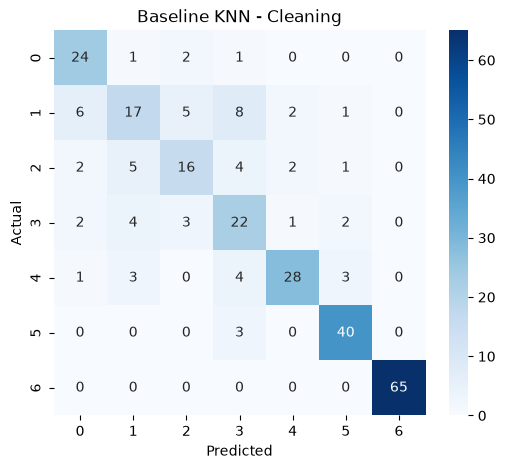


OPTIMIZED KNN
Best Parameter : {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score  : 0.7762074510298383
Accuracy          : 0.7950
Precision (Macro) : 0.7712
Recall (Macro)    : 0.7735
F1 Score (Macro)  : 0.7673
Balanced Accuracy : 0.7735


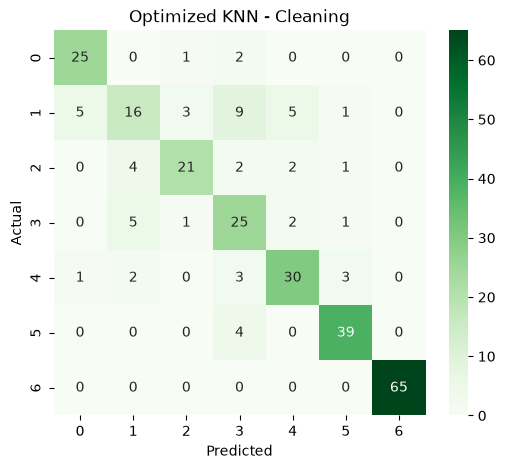

DATASET : Undersampling

BASELINE KNN
Accuracy          : 0.7590
Precision (Macro) : 0.7178
Recall (Macro)    : 0.7310
F1 Score (Macro)  : 0.7164
Balanced Accuracy : 0.7310


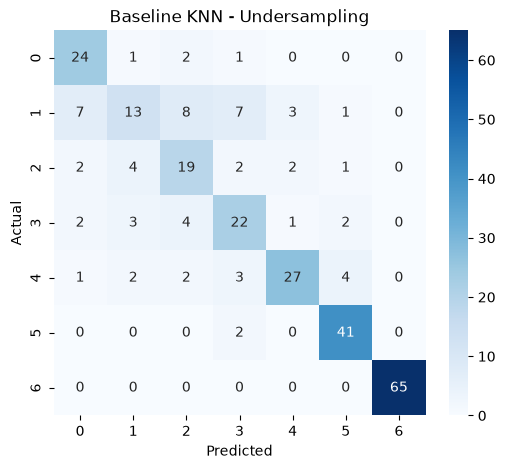


OPTIMIZED KNN
Best Parameter : {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score  : 0.7372409895033111
Accuracy          : 0.7950
Precision (Macro) : 0.7549
Recall (Macro)    : 0.7750
F1 Score (Macro)  : 0.7573
Balanced Accuracy : 0.7750


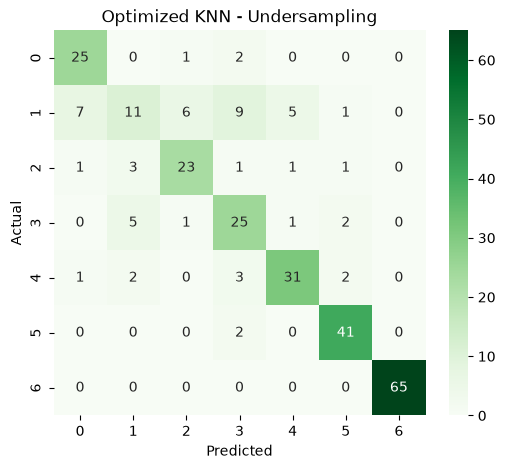

DATASET : SMOTE

BASELINE KNN
Accuracy          : 0.7914
Precision (Macro) : 0.7648
Recall (Macro)    : 0.7648
F1 Score (Macro)  : 0.7605
Balanced Accuracy : 0.7648


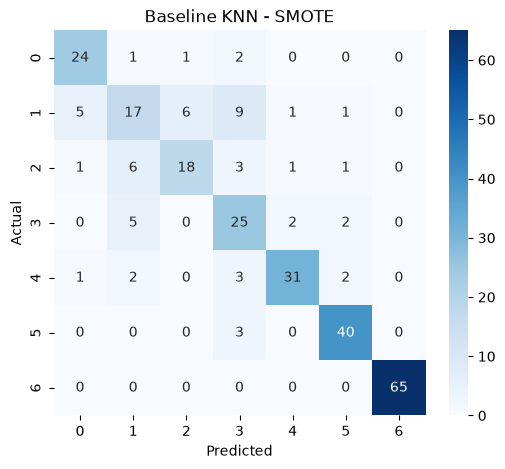


OPTIMIZED KNN
Best Parameter : {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score  : 0.9115403858866387
Accuracy          : 0.7986
Precision (Macro) : 0.7707
Recall (Macro)    : 0.7768
F1 Score (Macro)  : 0.7687
Balanced Accuracy : 0.7768


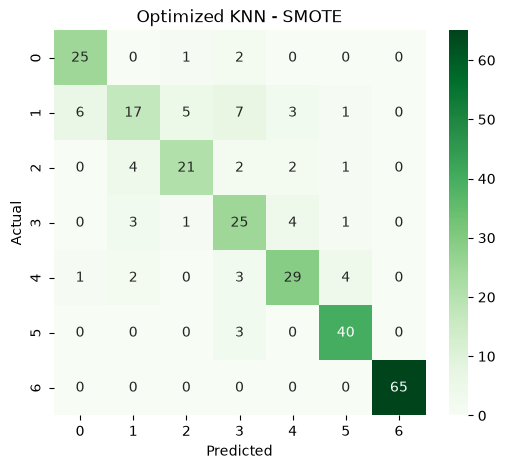



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Cleaning,Baseline,0.762590,0.727303,0.731659,0.724529,0.731659
1,Cleaning,Optimized,0.794964,0.771170,0.773516,0.767259,0.773516
2,Undersampling,Baseline,0.758993,0.717750,0.730952,0.716428,0.730952
3,Undersampling,Optimized,0.794964,0.754915,0.775033,0.757345,0.775033
4,SMOTE,Baseline,0.791367,0.764774,0.764777,0.760492,0.764777
5,SMOTE,Optimized,0.798561,0.770651,0.776839,0.768654,0.776839


In [26]:
datasets = {
    "Cleaning": (X_clean_train_scaled, y_clean_train),
    "Undersampling": (X_clean_under, y_clean_under),
    "SMOTE": (X_clean_over, y_clean_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE KNN")

    baseline_knn = KNeighborsClassifier()

    baseline_knn.fit(X_train, y_train)

    baseline_pred = baseline_knn.predict(X_clean_test_scaled)

    baseline_accuracy = accuracy_score(
        y_clean_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_clean_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline KNN - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED KNN")

    param_grid_knn = {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    }

    grid_knn = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid_knn,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_knn.fit(
        X_train,
        y_train
    )

    best_knn = grid_knn.best_estimator_

    print("Best Parameter :", grid_knn.best_params_)
    print("Best CV Score  :", grid_knn.best_score_)

    y_pred = best_knn.predict(
        X_clean_test_scaled
    )

    accuracy = accuracy_score(
        y_clean_test,
        y_pred
    )

    precision = precision_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_clean_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized KNN - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

### d. Pembuatan dan Evaluasi Model Decision Tree

DATASET : Cleaning

BASELINE Decision Tree
Accuracy          : 0.9245
Precision (Macro) : 0.9115
Recall (Macro)    : 0.9125
F1 Score (Macro)  : 0.9115
Balanced Accuracy : 0.9125


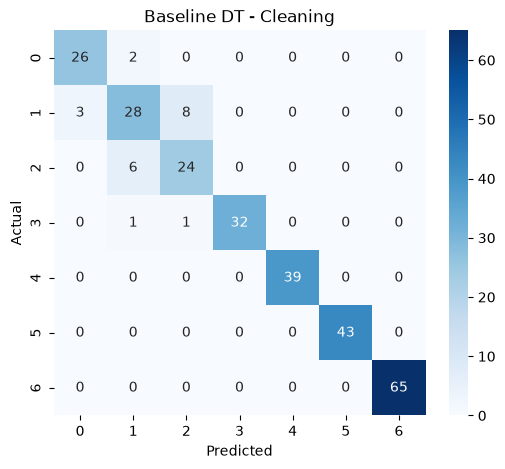


OPTIMIZED Decision Tree
Best Parameter : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score  : 0.9446365512361327
Accuracy          : 0.9173
Precision (Macro) : 0.9049
Recall (Macro)    : 0.9023
F1 Score (Macro)  : 0.9032
Balanced Accuracy : 0.9023


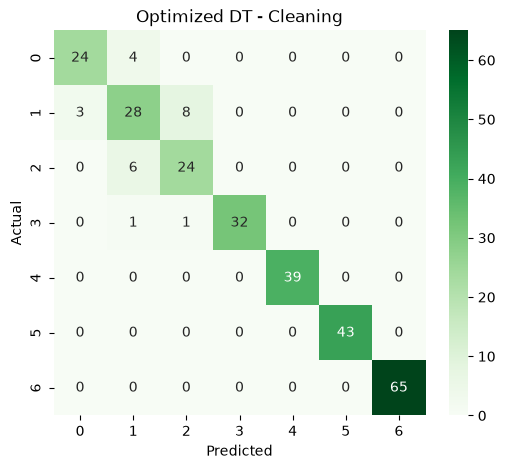

DATASET : Undersampling

BASELINE Decision Tree
Accuracy          : 0.9353
Precision (Macro) : 0.9242
Recall (Macro)    : 0.9246
F1 Score (Macro)  : 0.9241
Balanced Accuracy : 0.9246


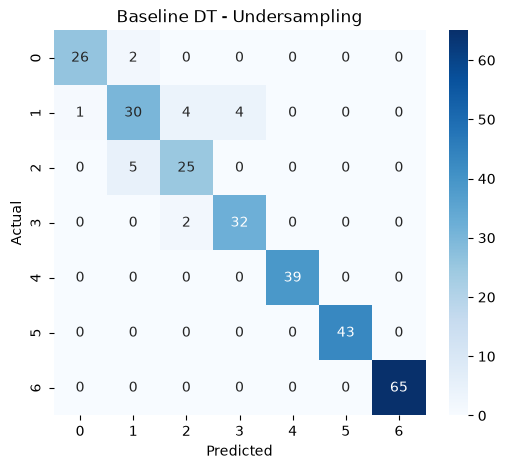


OPTIMIZED Decision Tree
Best Parameter : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score  : 0.9175969091365964
Accuracy          : 0.9388
Precision (Macro) : 0.9284
Recall (Macro)    : 0.9288
F1 Score (Macro)  : 0.9283
Balanced Accuracy : 0.9288


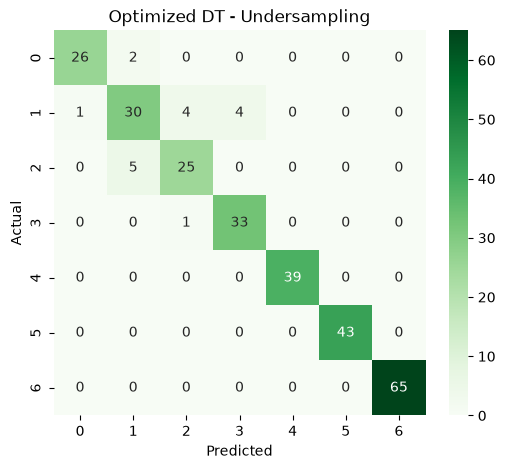

DATASET : SMOTE

BASELINE Decision Tree
Accuracy          : 0.9568
Precision (Macro) : 0.9500
Recall (Macro)    : 0.9502
F1 Score (Macro)  : 0.9499
Balanced Accuracy : 0.9502


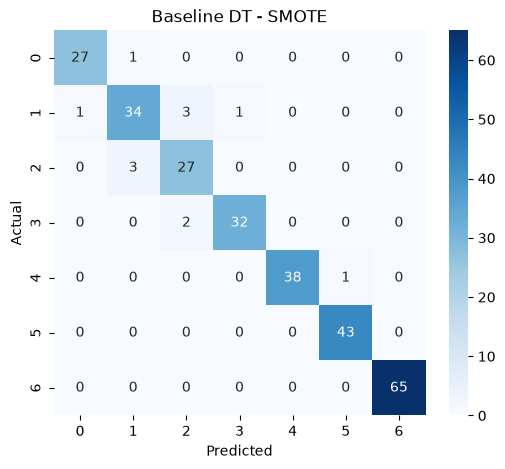


OPTIMIZED Decision Tree
Best Parameter : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score  : 0.9551614763412977
Accuracy          : 0.9568
Precision (Macro) : 0.9500
Recall (Macro)    : 0.9502
F1 Score (Macro)  : 0.9499
Balanced Accuracy : 0.9502


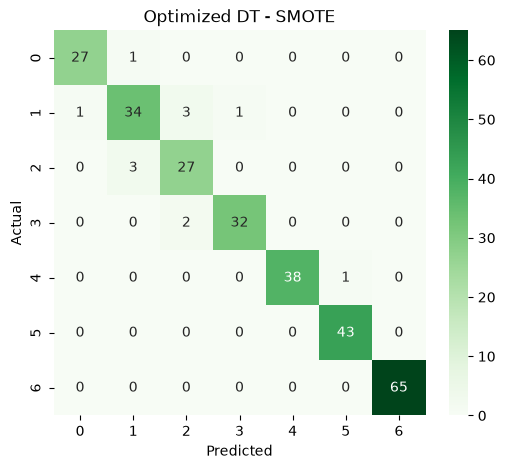



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Cleaning,Baseline,0.924460,0.911512,0.912528,0.911532,0.912528
1,Cleaning,Optimized,0.917266,0.904873,0.902324,0.903183,0.902324
2,Undersampling,Baseline,0.935252,0.924159,0.924616,0.924127,0.924616
3,Undersampling,Optimized,0.938849,0.928428,0.928818,0.928263,0.928818
4,SMOTE,Baseline,0.956835,0.949963,0.950231,0.949873,0.950231
5,SMOTE,Optimized,0.956835,0.949963,0.950231,0.949873,0.950231


In [27]:
datasets = {
    "Cleaning": (X_clean_train_scaled, y_clean_train),
    "Undersampling": (X_clean_under, y_clean_under),
    "SMOTE": (X_clean_over, y_clean_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE Decision Tree")

    baseline_dt = DecisionTreeClassifier(random_state=42)

    baseline_dt.fit(X_train, y_train)

    baseline_pred = baseline_dt.predict(X_clean_test_scaled)

    baseline_accuracy = accuracy_score(
        y_clean_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_clean_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline DT - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED Decision Tree")

    param_grid_dt = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    grid_dt = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=param_grid_dt,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_dt.fit(
        X_train,
        y_train
    )

    best_dt = grid_dt.best_estimator_

    print("Best Parameter :", grid_dt.best_params_)
    print("Best CV Score  :", grid_dt.best_score_)

    y_pred = best_dt.predict(
        X_clean_test_scaled
    )

    accuracy = accuracy_score(
        y_clean_test,
        y_pred
    )

    precision = precision_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_clean_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized DT - {name}')
    
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

### e. Pembuatan dan Evaluasi Model Naive Bayes

DATASET : Cleaning

BASELINE naive Bayes
Accuracy          : 0.5719
Precision (Macro) : 0.4677
Recall (Macro)    : 0.4981
F1 Score (Macro)  : 0.4073
Balanced Accuracy : 0.4981


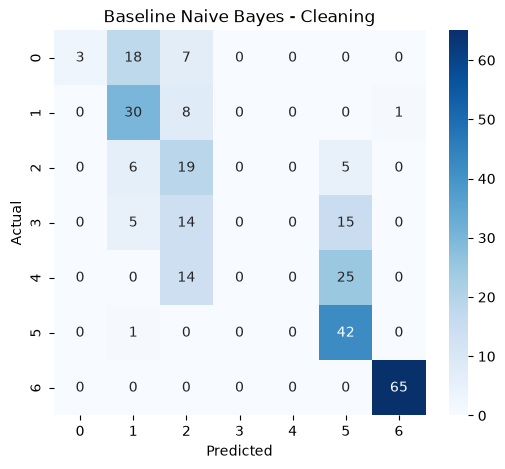


OPTIMIZED Naive Bayes
Best Parameter : {'var_smoothing': 1e-05}
Best CV Score  : 0.5629046073383656
Accuracy          : 0.6727
Precision (Macro) : 0.7107
Recall (Macro)    : 0.6147
F1 Score (Macro)  : 0.5955
Balanced Accuracy : 0.6147


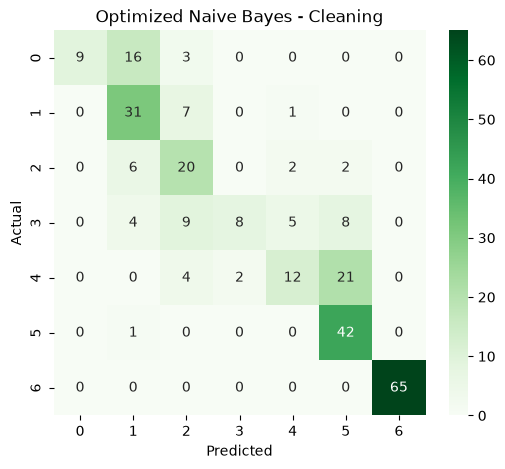

DATASET : Undersampling

BASELINE naive Bayes
Accuracy          : 0.5791
Precision (Macro) : 0.5534
Recall (Macro)    : 0.4925
F1 Score (Macro)  : 0.4582
Balanced Accuracy : 0.4925


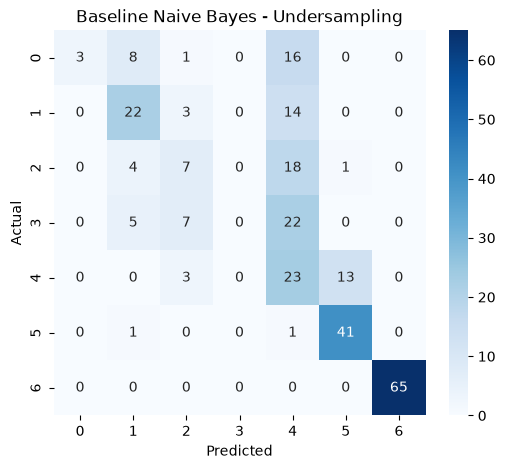


OPTIMIZED Naive Bayes
Best Parameter : {'var_smoothing': 1e-05}
Best CV Score  : 0.5304736925118642
Accuracy          : 0.6511
Precision (Macro) : 0.7002
Recall (Macro)    : 0.5799
F1 Score (Macro)  : 0.5768
Balanced Accuracy : 0.5799


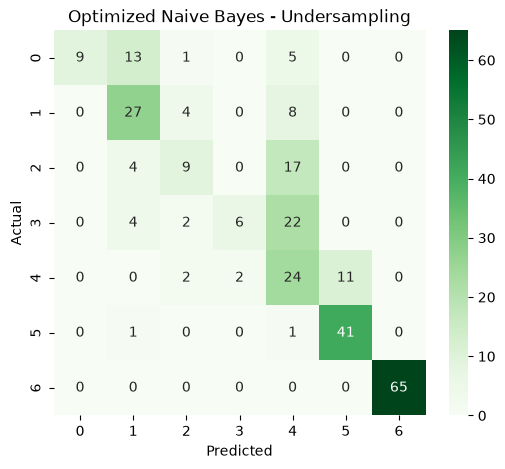

DATASET : SMOTE

BASELINE naive Bayes
Accuracy          : 0.6007
Precision (Macro) : 0.7635
Recall (Macro)    : 0.5341
F1 Score (Macro)  : 0.4640
Balanced Accuracy : 0.5341


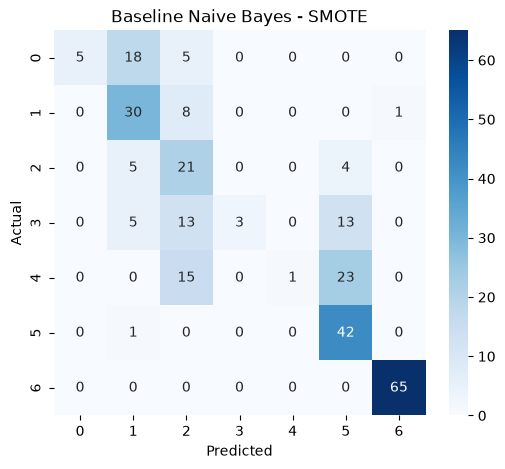


OPTIMIZED Naive Bayes
Best Parameter : {'var_smoothing': 1e-05}
Best CV Score  : 0.6459564416044716
Accuracy          : 0.7086
Precision (Macro) : 0.7260
Recall (Macro)    : 0.6558
F1 Score (Macro)  : 0.6456
Balanced Accuracy : 0.6558


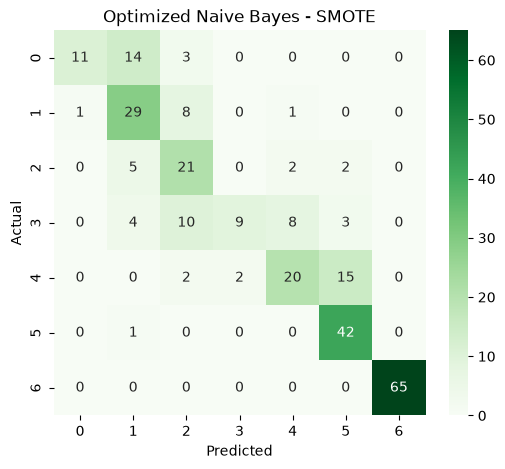



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Cleaning,Baseline,0.571942,0.467723,0.498064,0.407310,0.498064
1,Cleaning,Optimized,0.672662,0.710706,0.614671,0.595452,0.614671
2,Undersampling,Baseline,0.579137,0.553353,0.492544,0.458231,0.492544
3,Undersampling,Optimized,0.651079,0.700167,0.579869,0.576827,0.579869
4,SMOTE,Baseline,0.600719,0.763461,0.534060,0.464047,0.534060
5,SMOTE,Optimized,0.708633,0.725982,0.655817,0.645633,0.655817


In [28]:
datasets = {
    "Cleaning": (X_clean_train_scaled, y_clean_train),
    "Undersampling": (X_clean_under, y_clean_under),
    "SMOTE": (X_clean_over, y_clean_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE naive Bayes")

    baseline_nb = GaussianNB()

    baseline_nb.fit(X_train, y_train)

    baseline_pred = baseline_nb.predict(X_clean_test_scaled)

    baseline_accuracy = accuracy_score(
        y_clean_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_clean_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline Naive Bayes - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED Naive Bayes")

    param_grid_nb = {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
        
    
    }

    grid_nb = GridSearchCV(
        estimator=GaussianNB(),
        param_grid=param_grid_nb,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_nb.fit(
        X_train,
        y_train
    )

    best_nb = grid_nb.best_estimator_

    print("Best Parameter :", grid_nb.best_params_)
    print("Best CV Score  :", grid_nb.best_score_)

    y_pred = best_nb.predict(
        X_clean_test_scaled
    )

    accuracy = accuracy_score(
        y_clean_test,
        y_pred
    )

    precision = precision_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_clean_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized Naive Bayes - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

### f. Pembuatan dan Evaluasi Model Random Forest

DATASET : Cleaning

BASELINE Random Forest
Accuracy          : 0.9496
Precision (Macro) : 0.9470
Recall (Macro)    : 0.9371
F1 Score (Macro)  : 0.9403
Balanced Accuracy : 0.9371


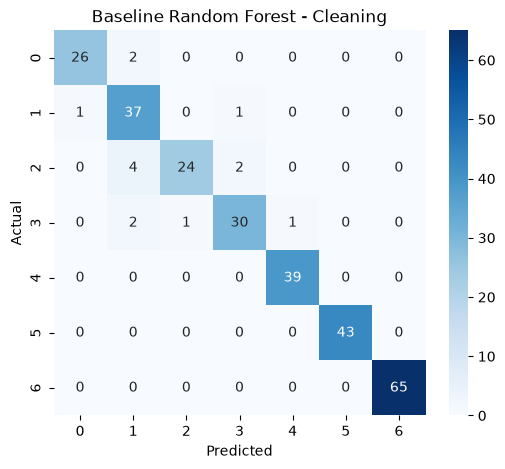


OPTIMIZED Random Forest
Best Parameter : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score  : 0.9544508038748202
Accuracy          : 0.9496
Precision (Macro) : 0.9492
Recall (Macro)    : 0.9357
F1 Score (Macro)  : 0.9401
Balanced Accuracy : 0.9357


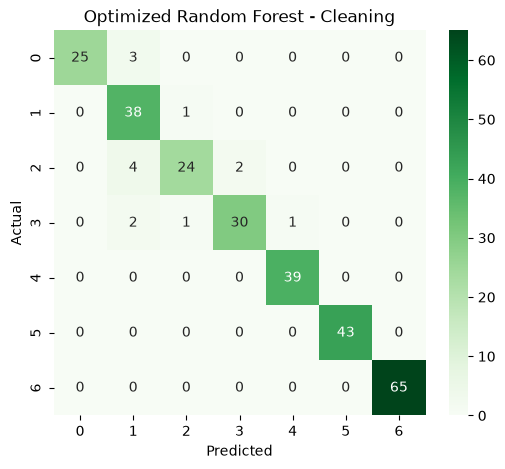

DATASET : Undersampling

BASELINE Random Forest
Accuracy          : 0.9388
Precision (Macro) : 0.9316
Recall (Macro)    : 0.9266
F1 Score (Macro)  : 0.9283
Balanced Accuracy : 0.9266


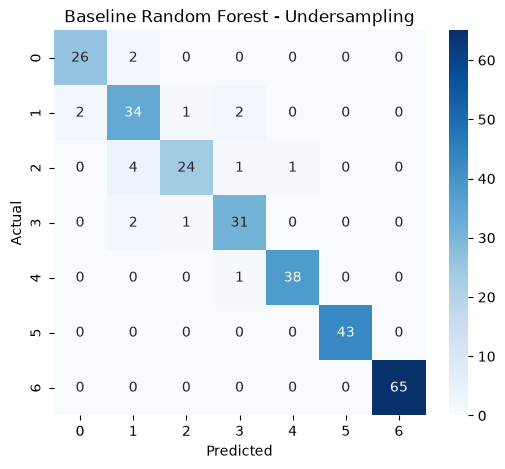


OPTIMIZED Random Forest
Best Parameter : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score  : 0.9394234936555168
Accuracy          : 0.9460
Precision (Macro) : 0.9402
Recall (Macro)    : 0.9356
F1 Score (Macro)  : 0.9373
Balanced Accuracy : 0.9356


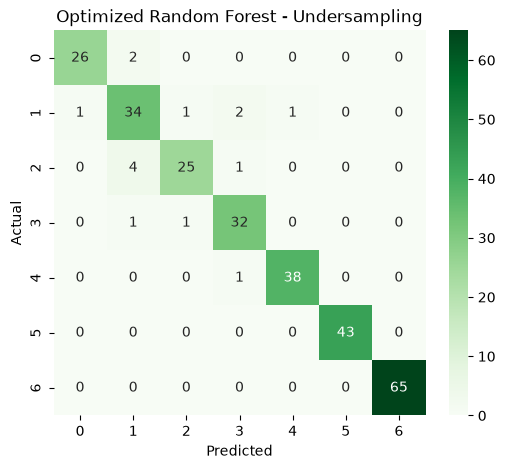

DATASET : SMOTE

BASELINE Random Forest
Accuracy          : 0.9568
Precision (Macro) : 0.9595
Recall (Macro)    : 0.9450
F1 Score (Macro)  : 0.9495
Balanced Accuracy : 0.9450


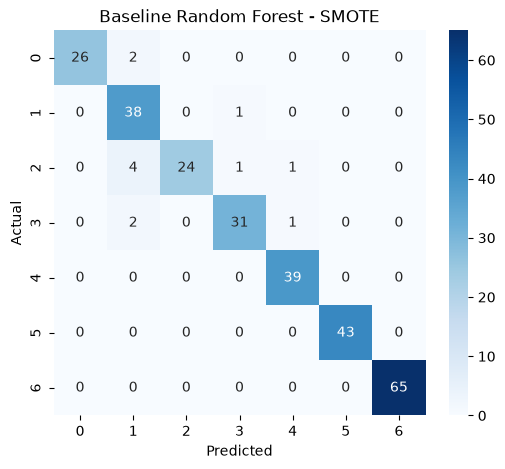


OPTIMIZED Random Forest
Best Parameter : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score  : 0.9736872643687692
Accuracy          : 0.9568
Precision (Macro) : 0.9595
Recall (Macro)    : 0.9450
F1 Score (Macro)  : 0.9495
Balanced Accuracy : 0.9450


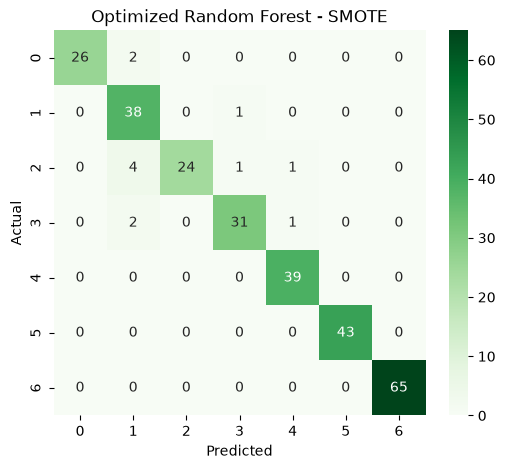



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Cleaning,Baseline,0.949640,0.947039,0.937092,0.940285,0.937092
1,Cleaning,Optimized,0.949640,0.949155,0.935653,0.940099,0.935653
2,Undersampling,Baseline,0.938849,0.931606,0.926641,0.928304,0.926641
3,Undersampling,Optimized,0.946043,0.940201,0.935605,0.937327,0.935605
4,SMOTE,Baseline,0.956835,0.959529,0.944956,0.949478,0.944956
5,SMOTE,Optimized,0.956835,0.959529,0.944956,0.949478,0.944956


In [29]:
datasets = {
    "Cleaning": (X_clean_train_scaled, y_clean_train),
    "Undersampling": (X_clean_under, y_clean_under),
    "SMOTE": (X_clean_over, y_clean_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE Random Forest")

    baseline_rf = RandomForestClassifier(random_state=42)

    baseline_rf.fit(X_train, y_train)

    baseline_pred = baseline_rf.predict(X_clean_test_scaled)

    baseline_accuracy = accuracy_score(
        y_clean_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_clean_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline Random Forest - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED Random Forest")

    param_grid_rf = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    grid_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid_rf,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_rf.fit(
        X_train,
        y_train
    )

    best_rf = grid_rf.best_estimator_

    print("Best Parameter :", grid_rf.best_params_)
    print("Best CV Score  :", grid_rf.best_score_)

    y_pred = best_rf.predict(
        X_clean_test_scaled
    )

    accuracy = accuracy_score(
        y_clean_test,
        y_pred
    )

    precision = precision_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_clean_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized Random Forest - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

### g. Pembuatan dan Evaluasi Model SVM

DATASET : Cleaning

BASELINE SVM
Accuracy          : 0.8273
Precision (Macro) : 0.8036
Recall (Macro)    : 0.7985
F1 Score (Macro)  : 0.8005
Balanced Accuracy : 0.7985


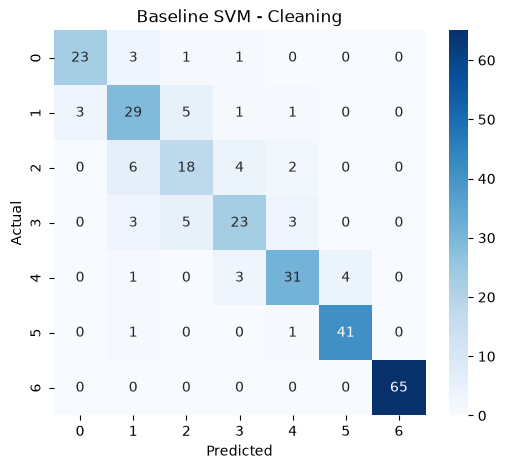


OPTIMIZED SVM
Best Parameter : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.9614213201021435
Best Parameter : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.9614213201021435
Accuracy          : 0.9640
Precision (Macro) : 0.9571
Recall (Macro)    : 0.9610
F1 Score (Macro)  : 0.9580
Balanced Accuracy : 0.9610


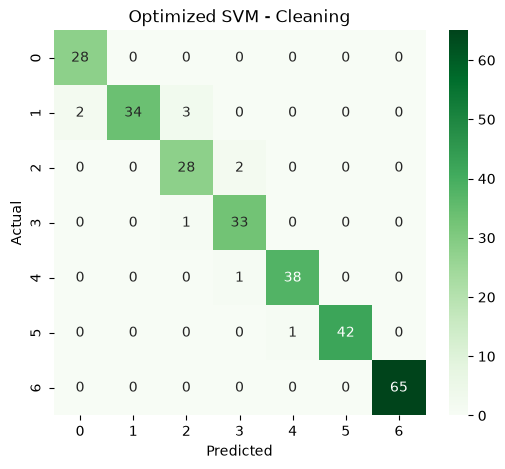

DATASET : Undersampling

BASELINE SVM
Accuracy          : 0.7914
Precision (Macro) : 0.7591
Recall (Macro)    : 0.7614
F1 Score (Macro)  : 0.7592
Balanced Accuracy : 0.7614


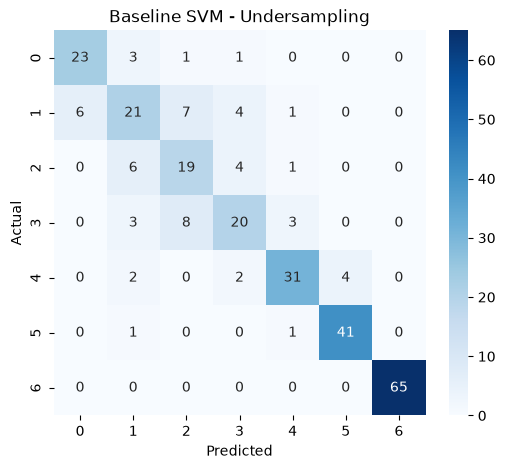


OPTIMIZED SVM
Best Parameter : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.9492781095921414
Best Parameter : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score  : 0.9492781095921414
Accuracy          : 0.9353
Precision (Macro) : 0.9230
Recall (Macro)    : 0.9259
F1 Score (Macro)  : 0.9234
Balanced Accuracy : 0.9259


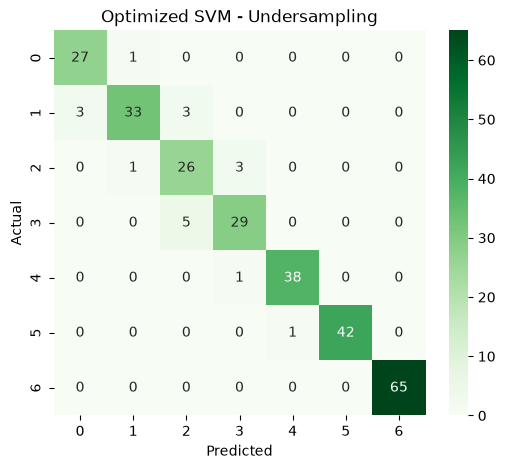

DATASET : SMOTE

BASELINE SVM
Accuracy          : 0.8417
Precision (Macro) : 0.8202
Recall (Macro)    : 0.8157
F1 Score (Macro)  : 0.8173
Balanced Accuracy : 0.8157


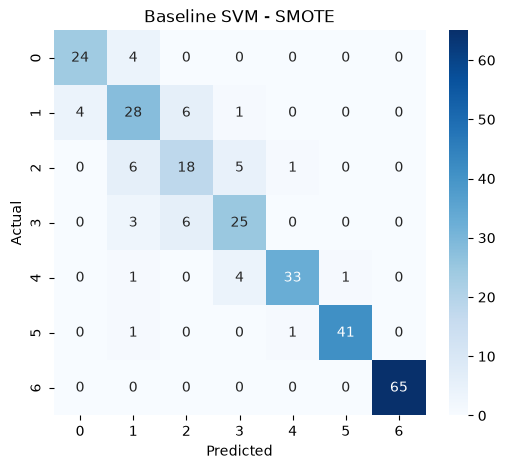


OPTIMIZED SVM
Best Parameter : {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV Score  : 0.9767039321315021
Best Parameter : {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV Score  : 0.9767039321315021
Accuracy          : 0.9353
Precision (Macro) : 0.9214
Recall (Macro)    : 0.9244
F1 Score (Macro)  : 0.9223
Balanced Accuracy : 0.9244


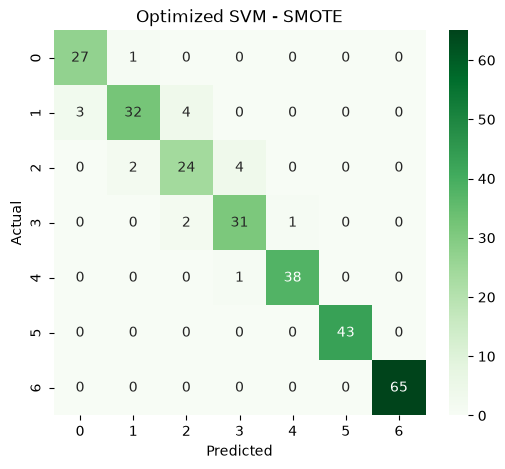



HASIL PERBANDINGAN BASELINE DAN OPTIMIZED


,Dataset,Model,Accuracy,Precision,Recall,Macro F1,Balanced Accuracy
0,Cleaning,Baseline,0.827338,0.803625,0.798550,0.800474,0.798550
1,Cleaning,Optimized,0.964029,0.957051,0.960974,0.957957,0.960974
2,Undersampling,Baseline,0.791367,0.759058,0.761403,0.759232,0.761403
3,Undersampling,Optimized,0.935252,0.922959,0.925879,0.923385,0.925879
4,SMOTE,Baseline,0.841727,0.820234,0.815718,0.817329,0.815718
5,SMOTE,Optimized,0.935252,0.921394,0.924417,0.922282,0.924417


In [30]:
datasets = {
    "Cleaning": (X_clean_train_scaled, y_clean_train),
    "Undersampling": (X_clean_under, y_clean_under),
    "SMOTE": (X_clean_over, y_clean_over)
}

results = []

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, (X_train, y_train) in datasets.items():

    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    # =====================================================
    # BASELINE MODEL
    # =====================================================

    print("\nBASELINE SVM")

    baseline_svm = SVC(random_state=42)

    baseline_svm.fit(X_train, y_train)

    baseline_pred = baseline_svm.predict(X_clean_test_scaled)

    baseline_accuracy = accuracy_score(
        y_clean_test,
        baseline_pred
    )

    baseline_precision = precision_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_recall = recall_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_f1 = f1_score(
        y_clean_test,
        baseline_pred,
        average='macro'
    )

    baseline_balanced = balanced_accuracy_score(
        y_clean_test,
        baseline_pred
    )

    print(f"Accuracy          : {baseline_accuracy:.4f}")
    print(f"Precision (Macro) : {baseline_precision:.4f}")
    print(f"Recall (Macro)    : {baseline_recall:.4f}")
    print(f"F1 Score (Macro)  : {baseline_f1:.4f}")
    print(f"Balanced Accuracy : {baseline_balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "Macro F1": baseline_f1,
        "Balanced Accuracy": baseline_balanced
    })

    # ===============================
    # BASELINE CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        baseline_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(f'Baseline SVM - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # =====================================================
    # OPTIMIZED MODEL
    # =====================================================

    print("\nOPTIMIZED SVM")

    param_grid_svm = {
        'C': [0.1, 1, 10,100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    }

    grid_svm = GridSearchCV(
        estimator=SVC(random_state=42),
        param_grid=param_grid_svm,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_svm.fit(
        X_train,
        y_train
    )

    best_svm = grid_svm.best_estimator_

    print("Best Parameter :", grid_svm.best_params_)
    print("Best CV Score  :", grid_svm.best_score_)

    y_pred = best_svm.predict(
        X_clean_test_scaled
    )

    grid_svm.fit(
        X_train,
        y_train
    )

    best_svm = grid_svm.best_estimator_

    print("Best Parameter :", grid_svm.best_params_)
    print("Best CV Score  :", grid_svm.best_score_)

    y_pred = best_svm.predict(
        X_clean_test_scaled
    )

    accuracy = accuracy_score(
        y_clean_test,
        y_pred
    )

    precision = precision_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_clean_test,
        y_pred,
        average='macro'
    )

    balanced = balanced_accuracy_score(
        y_clean_test,
        y_pred
    )

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    print(f"Balanced Accuracy : {balanced:.4f}")

    results.append({
        "Dataset": name,
        "Model": "Optimized",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Macro F1": f1,
        "Balanced Accuracy": balanced
    })

    # ===============================
    # OPTIMIZED CONFUSION MATRIX
    # ===============================

    cm = confusion_matrix(
        y_clean_test,
        y_pred
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens'
    )
    plt.title(f'Optimized SVM - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# =====================================================
# HASIL AKHIR
# =====================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("HASIL PERBANDINGAN BASELINE DAN OPTIMIZED")
print("="*80)

display(results_df)

# **4. Simpan Model**

In [31]:
import joblib
from sklearn.svm import SVC

# Simpan scaler
joblib.dump(scaler_clean, '../Models/scaler_minmax.joblib')

# Training model SVM dengan parameter terbaik hasil GridSearchCV
model = SVC(
    C=100,
    kernel='linear',
    gamma='scale',
    random_state=42,
    probability=True  
)
model.fit(X_clean_train_scaled, y_clean_train)

# Simpan model terbaik hasil GridSearchCV
joblib.dump(model, '../Models/model_terbaik.joblib')

# Load model
model_baru = joblib.load('../Models/model_terbaik.joblib')

### INTERPRETABILITAS

NameError: name 'feature_importance' is not defined

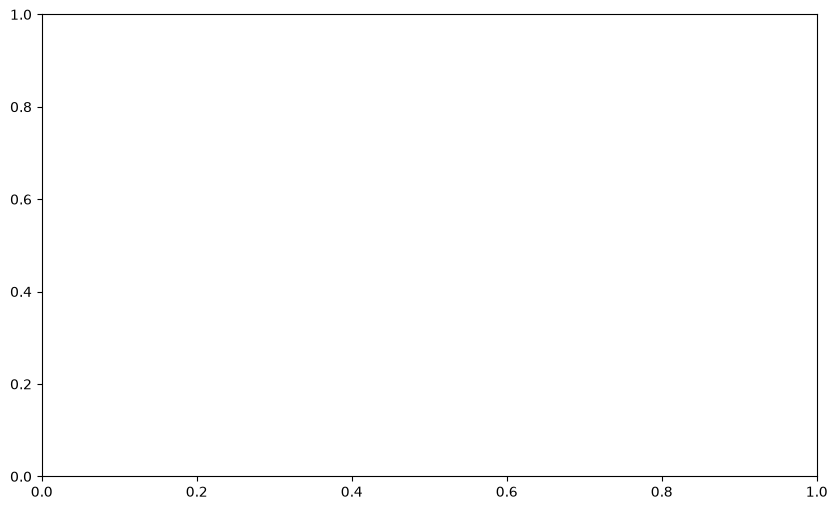

In [32]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Membuat figure
fig, ax = plt.subplots(figsize=(10,6))

# Normalisasi nilai importance
norm = mcolors.Normalize(
    vmin=feature_importance["Importance"].min(),
    vmax=feature_importance["Importance"].max()
)

# Colormap gradasi
cmap = cm.viridis
colors = cmap(norm(feature_importance["Importance"]))

# Bar chart
ax.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    xerr=feature_importance["Std"],
    color=colors,
    edgecolor="black",
    capsize=4
)

# Label
ax.set_xlabel("Penurunan F1-Macro Saat Fitur Diacak")
ax.set_ylabel("Feature")
ax.set_title("Feature Importance (Permutation) - SVM", fontsize=14, fontweight="bold")

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.35)

# Urutan feature terbesar di atas
ax.invert_yaxis()

# ==========================
# Tambahkan Colorbar (Legend)
# ==========================
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(
    "Importance Score",
    rotation=270,
    labelpad=20,
    fontsize=11
)

plt.tight_layout()
plt.show()

feature_importance

### ERROR ANALYSIS

In [ ]:
y_pred = model.predict(X_clean_test_scaled)  

hasil = pd.DataFrame({
    "Actual": y_clean_test,
    "Predicted": y_pred
})

X_error = X_clean_test.reset_index(drop=True)
hasil = hasil.reset_index(drop=True)
error_analysis = pd.concat([X_error, hasil], axis=1)

error = error_analysis[error_analysis["Actual"] != error_analysis["Predicted"]]
error

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Actual,Predicted
30,0,23.000000,1.500000,55.000000,1,1,3.000000,3.000000,1,0,2.000000,0,1.000000,0.000000,1,3,1,2
41,1,26.778684,1.780089,113.154640,1,1,2.219186,3.000000,1,0,2.092326,0,0.545919,1.742880,1,4,5,4
58,1,22.000000,1.700000,70.000000,1,1,2.000000,3.000000,1,0,1.000000,0,0.000000,1.000000,1,4,1,2
72,0,32.278869,1.646020,74.147443,1,1,2.885178,2.562895,1,0,1.017006,0,0.588673,0.916291,1,4,2,3
91,0,21.000000,1.720000,80.000000,1,1,2.000000,3.000000,2,0,2.000000,1,2.000000,1.000000,1,2,3,2
92,1,23.451595,1.670227,75.000000,1,1,2.000000,3.000000,1,0,2.000000,0,0.129163,1.983678,1,2,2,3
101,1,19.000000,1.750000,76.000000,1,1,3.000000,3.000000,1,0,2.000000,1,3.000000,1.000000,1,2,1,2
135,1,18.000000,1.870000,67.000000,1,1,3.000000,3.000000,2,0,3.000000,1,1.000000,1.000000,1,4,1,0
139,1,29.000000,1.690000,90.000000,1,0,2.000000,3.000000,1,0,3.000000,0,1.000000,0.000000,1,4,4,3
268,1,17.000000,1.700000,55.000000,0,1,3.000000,3.000000,3,0,2.000000,0,3.000000,1.000000,1,2,1,0


Dari 278 data uji, model SVM meleset pada 10 sampel (3,6%), dan yang menarik, seluruh kesalahan itu terjadi **antar kelas yang bertetangga langsung** — tidak ada satu pun kasus salah tebak yang melompat dua tingkat atau lebih, seperti memprediksi *Obesity Type III* padahal aslinya *Normal Weight*. Pola yang muncul umumnya berupa *Normal Weight* tertukar dengan *Overweight Level I* atau *Insufficient Weight*, serta *Overweight Level I* dan *Level II* yang saling tertukar; dan ketika BMI dihitung ulang dari tinggi dan berat pada baris-baris ini, terlihat pola yang konsisten — hampir semua sampel yang salah diklasifikasikan memiliki BMI persis di sekitar garis batas antar kategori (misalnya berkisar 24,2–24,8 untuk kasus *Normal*/*Overweight I*, tepat berdekatan dengan ambang 25). Ini menunjukkan bahwa kesalahan model bukan karena model gagal memahami pola data, melainkan karena sifat data itu sendiri: individu dengan BMI tepat di garis batas memang secara inheren ambigu untuk diklasifikasikan, bahkan bagi manusia sekalipun, dan hal ini juga sejalan dengan hasil *permutation importance* yang menunjukkan **Weight sebagai fitur paling dominan** (penurunan F1-macro 0,728 saat diacak), jauh di atas **Height** (0,322), **Gender** (0,139), dan **Age** (0,057), sementara fitur gaya hidup lain seperti kebiasaan merokok, konsumsi alkohol, hingga moda transportasi nyaris tidak berkontribusi. Dengan kata lain, karena model pada dasarnya "membaca" BMI melalui kombinasi Weight dan Height, wajar jika titik-titik yang paling sering salah diklasifikasikan justru berada tepat di garis batas nilai BMI — bukan tersebar acak di seluruh data — sehingga kesalahan yang terjadi sebenarnya mencerminkan batas alami antar kategori, bukan kelemahan mendasar pada model itu sendiri.

# **5. Demo Prediksi**

### STUDY CASE

Terdapat seorang pasien bernama Pak Adam, seorang **laki-laki (Gender = 1)** berusia **35 tahun (Age = 35)** dengan tinggi badan **175 cm atau 1.75 meter (Height = 1.75)** dan berat badan **95 kg (Weight = 95)**. Dari riwayat kesehatan keluarganya diketahui bahwa ia memiliki anggota keluarga yang mengalami obesitas, sehingga dikategorikan memiliki riwayat keluarga obesitas **(family_history_with_overweight = 1)**.

Dalam kesehariannya, Pak Adam memiliki kebiasaan mengonsumsi makanan tinggi kalori seperti gorengan dan makanan cepat saji, sehingga dikategorikan sering mengonsumsi makanan berkalori tinggi **(FAVC = 1)**. Konsumsi sayurnya tergolong tidak rutin, hanya sesekali dalam beberapa hari, sehingga berada pada kategori sedang **(FCVC = 2)**. Ia biasanya makan sebanyak **3 kali sehari (NCP = 3)**.

Di antara waktu makan utama, Pak Adam juga terkadang mengonsumsi camilan, sehingga masuk kategori kadang-kadang **(CAEC = 1)**. Ia tidak memiliki kebiasaan merokok **(SMOKE = 0)**. Untuk konsumsi air putih, ia minum sekitar **2 liter per hari (CH2O = 2)**, yang masih dalam batas cukup.

Namun, Pak Adam tidak melakukan pemantauan terhadap jumlah kalori yang dikonsumsi setiap hari **(SCC = 0)**. Aktivitas fisiknya tergolong rendah, karena hanya berolahraga sekitar **1 kali dalam seminggu (FAF = 1)**. Selain itu, ia juga menggunakan perangkat teknologi seperti ponsel atau komputer sekitar **1 jam per hari (TUE = 1)**.

Untuk konsumsi alkohol, Pak Adam tergolong jarang mengonsumsi, sehingga dikategorikan **(CALC = 1)**. Dalam aktivitas sehari-hari, ia biasanya menggunakan kendaraan seperti motor atau transportasi umum untuk berpindah tempat, yang dalam sistem dikodekan sebagai **(MTRANS = 2)**.

Berdasarkan seluruh informasi tersebut, maka data Pak Adam dapat direpresentasikan ke dalam bentuk numerik sebagai berikut:

**[1, 35, 1.75, 95, 1, 1, 2, 3, 1, 0, 2, 0, 1, 1, 1, 2]**

Data inilah yang kemudian digunakan sebagai input ke dalam model machine learning untuk memprediksi tingkat obesitas yang dialami oleh Pak Adam.


In [ ]:
import joblib

model = joblib.load('../Models/model_terbaik.joblib')

X_new = [[1,35,1.75,95,1,1,2,3,1,0,2,0,1,1,1,2]]

scaler = joblib.load('../Models/scaler_minmax.joblib')
X_scaled = scaler.transform(X_new)

pred = model.predict(X_scaled)

kelas = {
    0: 'Insufficient Weight',
    1: 'Normal Weight',
    2: 'Overweight Level I',
    3: 'Overweight Level II',
    4: 'Obesity Type I',
    5: 'Obesity Type II',
    6: 'Obesity Type III'
}

print("Kelas:", pred[0])
print("Interpretasi:", kelas[pred[0]])

Kelas: 4
Interpretasi: Obesity Type I
